# Machine Learning Concepts for Medical Professionals

**A Comprehensive Lecture Notebook with Hands-On Implementation**

---

### Dataset
**Pima Indians Diabetes Dataset** — [Kaggle Link](https://www.kaggle.com/datasets/vikasukani/diabetes-data-set)

This dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK). It contains diagnostic measurements from **768 female patients** of Pima Indian heritage, aged 21 and older. The clinical goal is to predict whether a patient has diabetes based on routine diagnostic measurements.

### Table of Contents

| Module | Topic |
|--------|-------|
| **1** | Introduction to Machine Learning Concepts |
| **2** | Supervised Learning: Linear and Logistic Regression |
| **3** | Unsupervised Learning: K-Means and Hierarchical Clustering |
| **4** | Implementation of Machine Learning Methods |

---


## Environment Setup & Data Loading

Run the cells below to load all required libraries and the dataset. If running locally (not on Kaggle), download the CSV from [https://www.kaggle.com/datasets/vikasukani/diabetes-data-set](https://www.kaggle.com/datasets/vikasukani/diabetes-data-set) and update the `file_path` variable.


In [ ]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, silhouette_score
)
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Display settings ──
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

print("✅ All libraries loaded successfully.")


✅ All libraries loaded successfully.


In [ ]:
# ── Load the Pima Indians Diabetes Dataset ──
# UPDATE THIS PATH if running locally:
# file_path = 'diabetes-dataset.csv'
file_path = '/content/diabetes-dataset.csv'

diabetes_data = pd.read_csv(file_path)

print(f"Dataset shape: {diabetes_data.shape}")
print(f"Columns: {list(diabetes_data.columns)}")
diabetes_data.head()


Dataset shape: (2000, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


### Understanding the Dataset

Each row represents one female patient (age ≥ 21) of Pima Indian heritage. The features are routine clinical and diagnostic measurements:

| Column | Description | Units | Clinical Relevance |
|--------|-------------|-------|-------------------|
| `Pregnancies` | Number of pregnancies | count | Gestational diabetes risk factor; multiparity associated with metabolic changes |
| `Glucose` | Plasma glucose concentration at 2 hours in an oral glucose tolerance test (OGTT) | mg/dL | **Gold standard** for diabetes diagnosis. Normal < 140, Pre-diabetic 140–199, Diabetic ≥ 200 |
| `BloodPressure` | Diastolic blood pressure | mmHg | Hypertension is a common comorbidity of Type 2 diabetes; target < 80 mmHg |
| `SkinThickness` | Triceps skin fold thickness | mm | Surrogate measure for subcutaneous fat; correlates with insulin resistance |
| `Insulin` | 2-hour serum insulin | μU/mL | Reflects beta-cell function and insulin resistance; elevated in early T2DM |
| `BMI` | Body mass index (weight/height²) | kg/m² | Overweight (≥ 25) and obesity (≥ 30) are major risk factors for diabetes |
| `DiabetesPedigreeFunction` | Diabetes pedigree function | score | Genetic risk score based on family history — higher = more genetic predisposition |
| `Age` | Patient age | years | Risk increases with age, especially after 45 |
| `Outcome` | Diabetes diagnosis | 0 = No, 1 = Yes | **Target variable** — based on WHO criteria |

#### Important Data Quality Note
Several features contain **zero values that are biologically impossible** (e.g., Glucose = 0, BloodPressure = 0, BMI = 0). These represent **missing data coded as zeros**, which is a common issue in clinical datasets. We will address this during preprocessing.


In [ ]:
# ── Basic data inspection ──
print("── Data Types ──")
print(diabetes_data.dtypes)
print(f"\n── Shape: {diabetes_data.shape[0]} patients, {diabetes_data.shape[1]} features ──")
print(f"\n── Outcome Distribution ──")
print(diabetes_data['Outcome'].value_counts())
print(f"\nDiabetes prevalence: {diabetes_data['Outcome'].mean():.1%}")


── Data Types ──
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

── Shape: 2000 patients, 9 features ──

── Outcome Distribution ──
Outcome
0    1316
1     684
Name: count, dtype: int64

Diabetes prevalence: 34.2%


In [ ]:
# ── Check for impossible zero values (missing data coded as 0) ──
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("── Count of zero values (likely missing data) ──")
for col in zero_cols:
    n_zeros = (diabetes_data[col] == 0).sum()
    pct = n_zeros / len(diabetes_data) * 100
    print(f"  {col:30s}: {n_zeros:3d} zeros ({pct:.1f}%)")

print("\n💡 Clinical note: A glucose of 0 mg/dL or BMI of 0 is not physiologically")
print("   possible in a living patient. These are missing values, not true zeros.")
print("   We will handle these appropriately in each module.")


── Count of zero values (likely missing data) ──
  Glucose                       :  13 zeros (0.7%)
  BloodPressure                 :  90 zeros (4.5%)
  SkinThickness                 : 573 zeros (28.6%)
  Insulin                       : 956 zeros (47.8%)
  BMI                           :  28 zeros (1.4%)

💡 Clinical note: A glucose of 0 mg/dL or BMI of 0 is not physiologically
   possible in a living patient. These are missing values, not true zeros.
   We will handle these appropriately in each module.


In [ ]:
# ── Replace impossible zeros with NaN for cleaner analysis ──
diabetes_clean = diabetes_data.copy()
for col in zero_cols:
    diabetes_clean[col] = diabetes_clean[col].replace(0, np.nan)

print("── Missing values after replacing zeros ──")
print(diabetes_clean.isnull().sum())
print(f"\nTotal complete cases: {diabetes_clean.dropna().shape[0]} / {len(diabetes_clean)}")


── Missing values after replacing zeros ──
Pregnancies                   0
Glucose                      13
BloodPressure                90
SkinThickness               573
Insulin                     956
BMI                          28
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total complete cases: 1035 / 2000


**Note**: The missing data situation is significant: Insulin has 47.8% zeros (missing) and SkinThickness has 28.6%. BloodPressure, Glucose, and BMI have smaller amounts. This means any model relying heavily on Insulin or SkinThickness is working with incomplete information for nearly half the patients.


---

# Module 1: Introduction to Machine Learning Concepts

---

## 1.1 What Is Machine Learning?

Machine learning (ML) is a subfield of artificial intelligence in which computer algorithms **learn patterns directly from data** rather than being explicitly programmed with rules.

**A clinical analogy:** Consider how an experienced physician develops diagnostic intuition. After seeing thousands of patients, they learn to recognise subtle combinations of symptoms, lab values, and imaging findings that point toward a diagnosis — often before they can fully articulate the rules they are applying. Machine learning formalises this same process mathematically: given enough examples of patients with known outcomes, an algorithm can learn the patterns that distinguish, for example, diabetic from non-diabetic patients.

The critical difference is **scale and consistency**:
- A clinician might integrate 5–10 variables at once; ML algorithms can handle hundreds or thousands simultaneously
- A human's pattern recognition varies with fatigue, cognitive load, and experience; ML models produce the same output given the same input, every time
- ML can process millions of records in seconds — far beyond human capacity

### Why Machine Learning Matters in Medicine

1. **The data explosion:** Electronic health records, wearables, genomic sequencing, and medical imaging are generating more data than humans can process. A single hospitalisation can generate over 100,000 data points.

2. **Diagnostic support:** ML models have achieved expert-level performance in detecting diabetic retinopathy from retinal images, identifying skin cancer from photographs, and flagging early signs of sepsis from vital signs — tasks where pattern recognition at scale is critical.

3. **Risk stratification:** Instead of treating all patients the same, ML can identify who is at highest risk for complications (e.g., hospital readmission, cardiovascular events, diabetic ketoacidosis), enabling **proactive, personalised care**.

4. **Drug discovery:** ML accelerates the identification of candidate drug molecules by predicting which compounds are most likely to bind to a target protein, reducing years of laboratory screening.

5. **Operational efficiency:** Predicting patient volumes, optimising operating room schedules, and flagging coding errors all benefit from ML, freeing clinicians to focus on patient care.

---

## 1.2 Types of Machine Learning

Machine learning algorithms fall into several broad categories, each suited to different clinical tasks:

### Supervised Learning
- **What it does:** Learns from labelled data — the algorithm sees both the input (patient features) and the correct answer (diagnosis), and learns to map one to the other.
- **Medical examples:**
  - Predicting diabetes (yes/no) from glucose, BMI, and age → **Classification**
  - Predicting systolic blood pressure from clinical measurements → **Regression**
  - Estimating length of hospital stay from admission data → **Regression**
  - Classifying chest X-rays as normal vs. pneumonia → **Classification**

### Unsupervised Learning
- **What it does:** Finds hidden structure in data **without labels** — the algorithm discovers natural groupings or patterns on its own.
- **Medical examples:**
  - Identifying patient subgroups ("phenotypes") in diabetes based on metabolic profiles → **Clustering**
  - Reducing 50 lab values to a few meaningful composite scores → **Dimensionality reduction**
  - Detecting unusual vital sign patterns that might indicate a rare condition → **Anomaly detection**

### Reinforcement Learning
- **What it does:** An agent learns to make sequential decisions by receiving rewards or penalties.
- **Medical examples:** Optimising ventilator settings in the ICU, personalising chemotherapy dosing schedules

### Semi-Supervised Learning
- **What it does:** Combines a small amount of labelled data with a large amount of unlabelled data.
- **Medical examples:** Training a radiology AI when only 500 scans are expert-labelled but 50,000 unlabelled scans are available

**In this course, we focus on supervised learning (Module 2) and unsupervised learning (Module 3).**

---

## 1.3 The Machine Learning Pipeline

Every ML project follows a general workflow. Understanding this pipeline is essential — most failures in medical ML come from **mistakes in the pipeline**, not from choosing the wrong algorithm.

```
1. Data Collection → 2. Data Cleaning → 3. Feature Engineering → 4. Train/Test Split
    → 5. Model Training → 6. Evaluation → 7. Iteration → 8. Deployment
```

### Each stage has medical-specific considerations:

**1. Data Collection**
- Source: EHRs, lab information systems, imaging PACS, patient-reported outcomes, wearables
- Challenges: De-identification (HIPAA/PHIPA compliance), consent, selection bias (who gets tested?), documentation variability across providers
- In our dataset: Data was collected from NIDDK's clinical study of Pima Indian women

**2. Data Cleaning**
- Missing values (our dataset has zeros where data is missing), outliers, inconsistent units
- Temporal issues: A lab result entered today might reflect a sample drawn yesterday
- **Clinical domain knowledge is irreplaceable here** — only a clinician would know that a "Glucose = 0" is an impossible value

**3. Feature Engineering**
- Creating new features from existing ones (e.g., BMI categories: underweight/normal/overweight/obese)
- Encoding categorical variables, handling date/time features
- Domain expertise: Knowing that the Glucose-to-Insulin ratio is more clinically meaningful than either value alone

**4. Train/Test Split**
- Must prevent **data leakage** — the test set must be truly "unseen"
- In temporal data: Always split by time (train on past, test on future) — never randomly
- In patient data: Split by patient, not by encounter — the same patient should not appear in both sets

**5. Model Training**
- Choose an algorithm, fit it to the training data
- Tune hyperparameters (settings that control model complexity)

**6. Evaluation**
- Use clinically meaningful metrics — not just accuracy
- In diabetes screening: Missing a diabetic patient (false negative) could be far worse than a false alarm (false positive)

**7. Iteration**
- Try different features, algorithms, and hyperparameters
- Return to earlier steps as needed

**8. Deployment & Monitoring**
- Integration with clinical workflows (EHR alerts, dashboards)
- Continuous monitoring for performance drift as patient populations change
- Regular retraining on new data

---

## 1.4 Ethical Considerations in Medical AI

Machine learning in healthcare raises important ethical questions that every practitioner must consider:

### Bias and Fairness
- Models trained primarily on one demographic group may perform poorly on others. Our dataset, for example, contains only Pima Indian women — the model should **not** be assumed to generalise to men, other ethnicities, or different age groups without validation.
- Pulse oximetry algorithms have been shown to overestimate oxygen saturation in patients with darker skin tones, leading to delayed treatment. ML models can inherit and amplify such biases if the training data reflects them.

### Transparency and Interpretability
- Clinicians need to understand **why** a model made a prediction to trust it and to explain it to patients.
- Linear and logistic regression are highly interpretable (each coefficient has a clear clinical meaning). More complex models (neural networks, ensemble methods) may require additional explainability techniques.

### Privacy and Security
- Patient data must be de-identified and stored securely.
- Regulations: HIPAA (US), PHIPA (Ontario), GDPR (EU), PIPEDA (Canada) all govern how health data can be used for ML.

### Clinical Validation
- A model that performs well on one hospital's data may fail on another's (distribution shift).
- External validation on independent cohorts is essential before any clinical deployment.
- Regulatory frameworks (Health Canada, FDA, EU MDR) are evolving to address Software as a Medical Device (SaMD).

---

## 1.5 Preparing Numerical Data for ML

Before feeding data into any ML algorithm, we need to prepare it properly. This section covers three essential preprocessing steps: **data splitting, normalisation, and feature selection**.

---


### 1.5.1 Data Splitting

Splitting the dataset into training and testing subsets is crucial for evaluating how well a machine learning model generalises to unseen data.

- **Training Set (80%):** Used to train the model — the algorithm learns patterns from this data
- **Testing Set (20%):** Held back completely — used only at the end to evaluate the model's true performance on data it has never seen

**Why is this important?**
- Without a separate test set, we cannot distinguish between a model that has truly learned generalisable patterns and one that has simply memorised the training data (overfitting)
- Think of it like an exam: studying the textbook is training; the exam itself is testing. If the exam questions were identical to the practice problems, you would not know if the student truly understood the material
- **Critical rule:** The test set must NEVER influence model training, feature selection, or preprocessing decisions

**Stratification:** When the outcome classes are imbalanced (e.g., 35% diabetic vs. 65% non-diabetic), we use stratified splitting to ensure both the training and testing sets have the same class proportions.


In [ ]:
# ── Separate features and target ──
features = diabetes_data.drop('Outcome', axis=1)
target = diabetes_data['Outcome']

# ── Split the dataset (80% train, 20% test, stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target)

print(f"Training set: {X_train.shape[0]} patients ({y_train.mean():.1%} diabetic)")
print(f"Testing set:  {X_test.shape[0]} patients ({y_test.mean():.1%} diabetic)")
print("✅ Class proportions preserved in both sets (stratified split)")


Training set: 1600 patients (34.2% diabetic)
Testing set:  400 patients (34.2% diabetic)
✅ Class proportions preserved in both sets (stratified split)


### 1.5.2 Normalisation (Feature Scaling)

Normalisation scales the data so all features contribute equally to the model. This is critical because features are measured in different units with very different ranges:

| Feature | Typical Range | Unit |
|---------|--------------|------|
| Pregnancies | 0–17 | count |
| Glucose | 44–199 | mg/dL |
| Insulin | 0–846 | μU/mL |
| BMI | 18–67 | kg/m² |
| Age | 21–81 | years |

Without scaling, **Insulin** (range ~800) would dominate algorithms that use distance or gradient calculations, even if **BMI** (range ~50) is actually more predictive.

**Two common approaches:**

1. **Standardisation (Z-score):** Transforms each feature to have mean = 0 and standard deviation = 1
   - Formula: z = (x − μ) / σ
   - Best for: Algorithms that assume normally distributed data (logistic regression, SVM, K-means)

2. **Min-Max Scaling:** Transforms each feature to the range [0, 1]
   - Formula: x_scaled = (x − min) / (max − min)
   - Best for: Neural networks, algorithms sensitive to magnitude

**Critical rule:** Always fit the scaler on the **training set only**, then apply the same transformation to the test set. If you fit on the entire dataset, you leak information from the test set into your preprocessing — this is called **data leakage**.


In [ ]:
# ── Standardise the features ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on training data ONLY
X_test_scaled = scaler.transform(X_test)          # Apply same transformation to test

print("Before scaling (first patient in training set):")
print(dict(zip(features.columns, X_train.iloc[0].values)))
print("\nAfter scaling (same patient):")
print(dict(zip(features.columns, X_train_scaled[0].round(2))))
print("\n💡 Notice: all values are now centred around 0 with similar scale")


Before scaling (first patient in training set):
{'Pregnancies': np.float64(0.0), 'Glucose': np.float64(102.0), 'BloodPressure': np.float64(86.0), 'SkinThickness': np.float64(17.0), 'Insulin': np.float64(105.0), 'BMI': np.float64(29.3), 'DiabetesPedigreeFunction': np.float64(0.695), 'Age': np.float64(27.0)}

After scaling (same patient):
{'Pregnancies': np.float64(-1.13), 'Glucose': np.float64(-0.6), 'BloodPressure': np.float64(0.87), 'SkinThickness': np.float64(-0.24), 'Insulin': np.float64(0.22), 'BMI': np.float64(-0.36), 'DiabetesPedigreeFunction': np.float64(0.71), 'Age': np.float64(-0.52)}

💡 Notice: all values are now centred around 0 with similar scale


### 1.5.3 Feature Selection

Feature selection identifies the most relevant features for the prediction task. Using too many irrelevant features can:
- **Reduce model performance** (noise overwhelms signal)
- **Increase computation time** unnecessarily
- **Make the model harder to interpret** for clinical use

#### ANOVA F-Score for Feature Selection

ANOVA (Analysis of Variance) F-score measures how well each feature discriminates between classes. It compares the variance **between** groups (diabetic vs. non-diabetic) to the variance **within** each group.

**How it works:**
- A high F-score means the feature values are very different between diabetic and non-diabetic patients — the feature is informative
- A low F-score means the feature values overlap heavily between the two groups — the feature is less useful

**Why ANOVA F-score?**
- Specifically designed for continuous features with categorical outcomes (exactly our situation)
- Fast, interpretable, and statistically grounded
- A good first-pass filter before training more complex models

**Limitations:**
- Tests each feature independently — cannot detect features that are only useful in combination
- Assumes features are approximately normally distributed
- For more sophisticated selection, consider Recursive Feature Elimination (RFE) or model-based importance (e.g., Random Forest feature importance)


In [ ]:
# ── ANOVA F-Score Feature Selection ──
k = 3  # Select top 3 features
anova_selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = anova_selector.fit_transform(X_train_scaled, y_train)
X_test_selected = anova_selector.transform(X_test_scaled)

# ── Display F-scores for all features ──
anova_scores = anova_selector.scores_
anova_results = pd.DataFrame({
    'Feature': features.columns,
    'F-Score': anova_scores
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print("── ANOVA F-Scores (higher = more discriminative) ──\n")
print(anova_results.to_string(index=False))

# ── Identify selected features ──
selected_mask = anova_selector.get_support()
selected_features = features.columns[selected_mask]
print(f"\n✅ Top {k} features selected: {list(selected_features)}")
print("\n💡 Glucose has the highest F-score — consistent with its role as the")
print("   primary diagnostic criterion for diabetes (OGTT ≥ 200 mg/dL).")


── ANOVA F-Scores (higher = more discriminative) ──

                 Feature    F-Score
                 Glucose 392.560520
                     BMI 139.002007
             Pregnancies  79.666123
                     Age  77.570363
DiabetesPedigreeFunction  34.461831
                 Insulin  28.144499
           SkinThickness  11.300597
           BloodPressure   3.865563

✅ Top 3 features selected: ['Pregnancies', 'Glucose', 'BMI']

💡 Glucose has the highest F-score — consistent with its role as the
   primary diagnostic criterion for diabetes (OGTT ≥ 200 mg/dL).


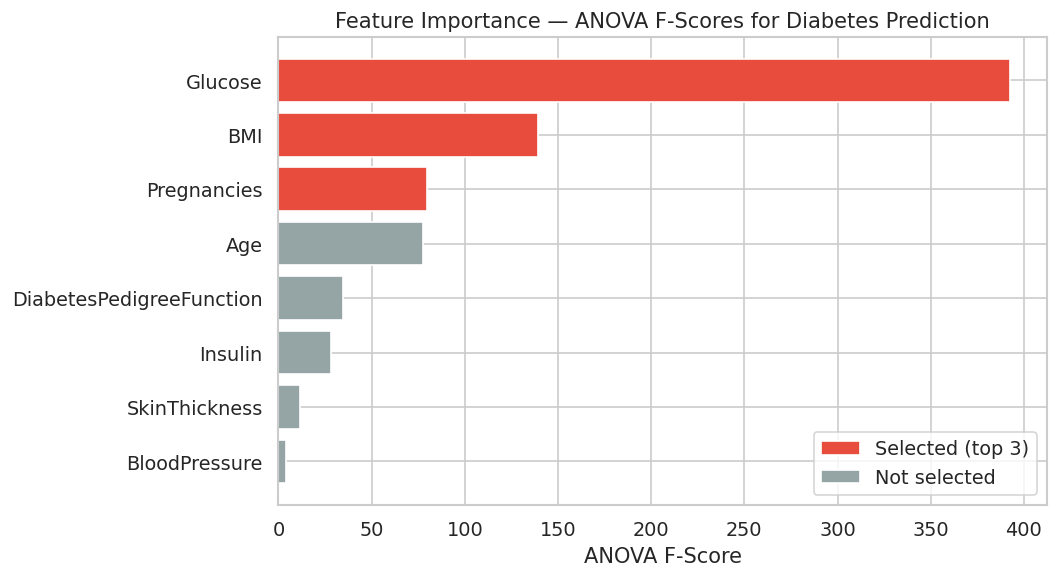

In [ ]:
# ── Visualise ANOVA F-Scores ──
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if s else '#3498db' for s in selected_mask[anova_results.index]]
bars = ax.barh(anova_results['Feature'], anova_results['F-Score'],
               color=['#e74c3c' if f in selected_features else '#95a5a6'
                      for f in anova_results['Feature']],
               edgecolor='white')
ax.set_xlabel('ANOVA F-Score')
ax.set_title('Feature Importance — ANOVA F-Scores for Diabetes Prediction')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Selected (top 3)'),
                   Patch(facecolor='#95a5a6', label='Not selected')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


**Note**: The top 3 features by discriminative power were Glucose (F=392.6), BMI (F=139.0), and Pregnancies (F=79.7). Glucose dominates as its F-score is nearly 3x higher than BMI's. This aligns perfectly with clinical practice: the oral glucose tolerance test is the primary diagnostic tool for diabetes. BloodPressure ranked last (F=3.9), meaning it barely distinguishes diabetic from non-diabetic patients in this dataset, which makes sense because hypertension is a comorbidity, not a direct diagnostic criterion.


### 1.5.4 Exploratory Data Analysis (EDA)

Before any modelling, we **always** explore the data thoroughly. This is analogous to performing a thorough history and physical examination before ordering investigations. It helps you understand what you are working with and catch potential problems early.


In [ ]:
# ── Summary statistics ──
print("── Descriptive Statistics ──\n")
diabetes_data.describe().round(1)


── Descriptive Statistics ──



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,3.7,121.2,69.1,20.9,80.3,32.2,0.5,33.1,0.3
std,3.3,32.1,19.2,16.1,111.2,8.1,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,63.5,0.0,0.0,27.4,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,40.0,32.3,0.4,29.0,0.0
75%,6.0,141.0,80.0,32.0,130.0,36.8,0.6,40.0,1.0
max,17.0,199.0,122.0,110.0,744.0,80.6,2.4,81.0,1.0


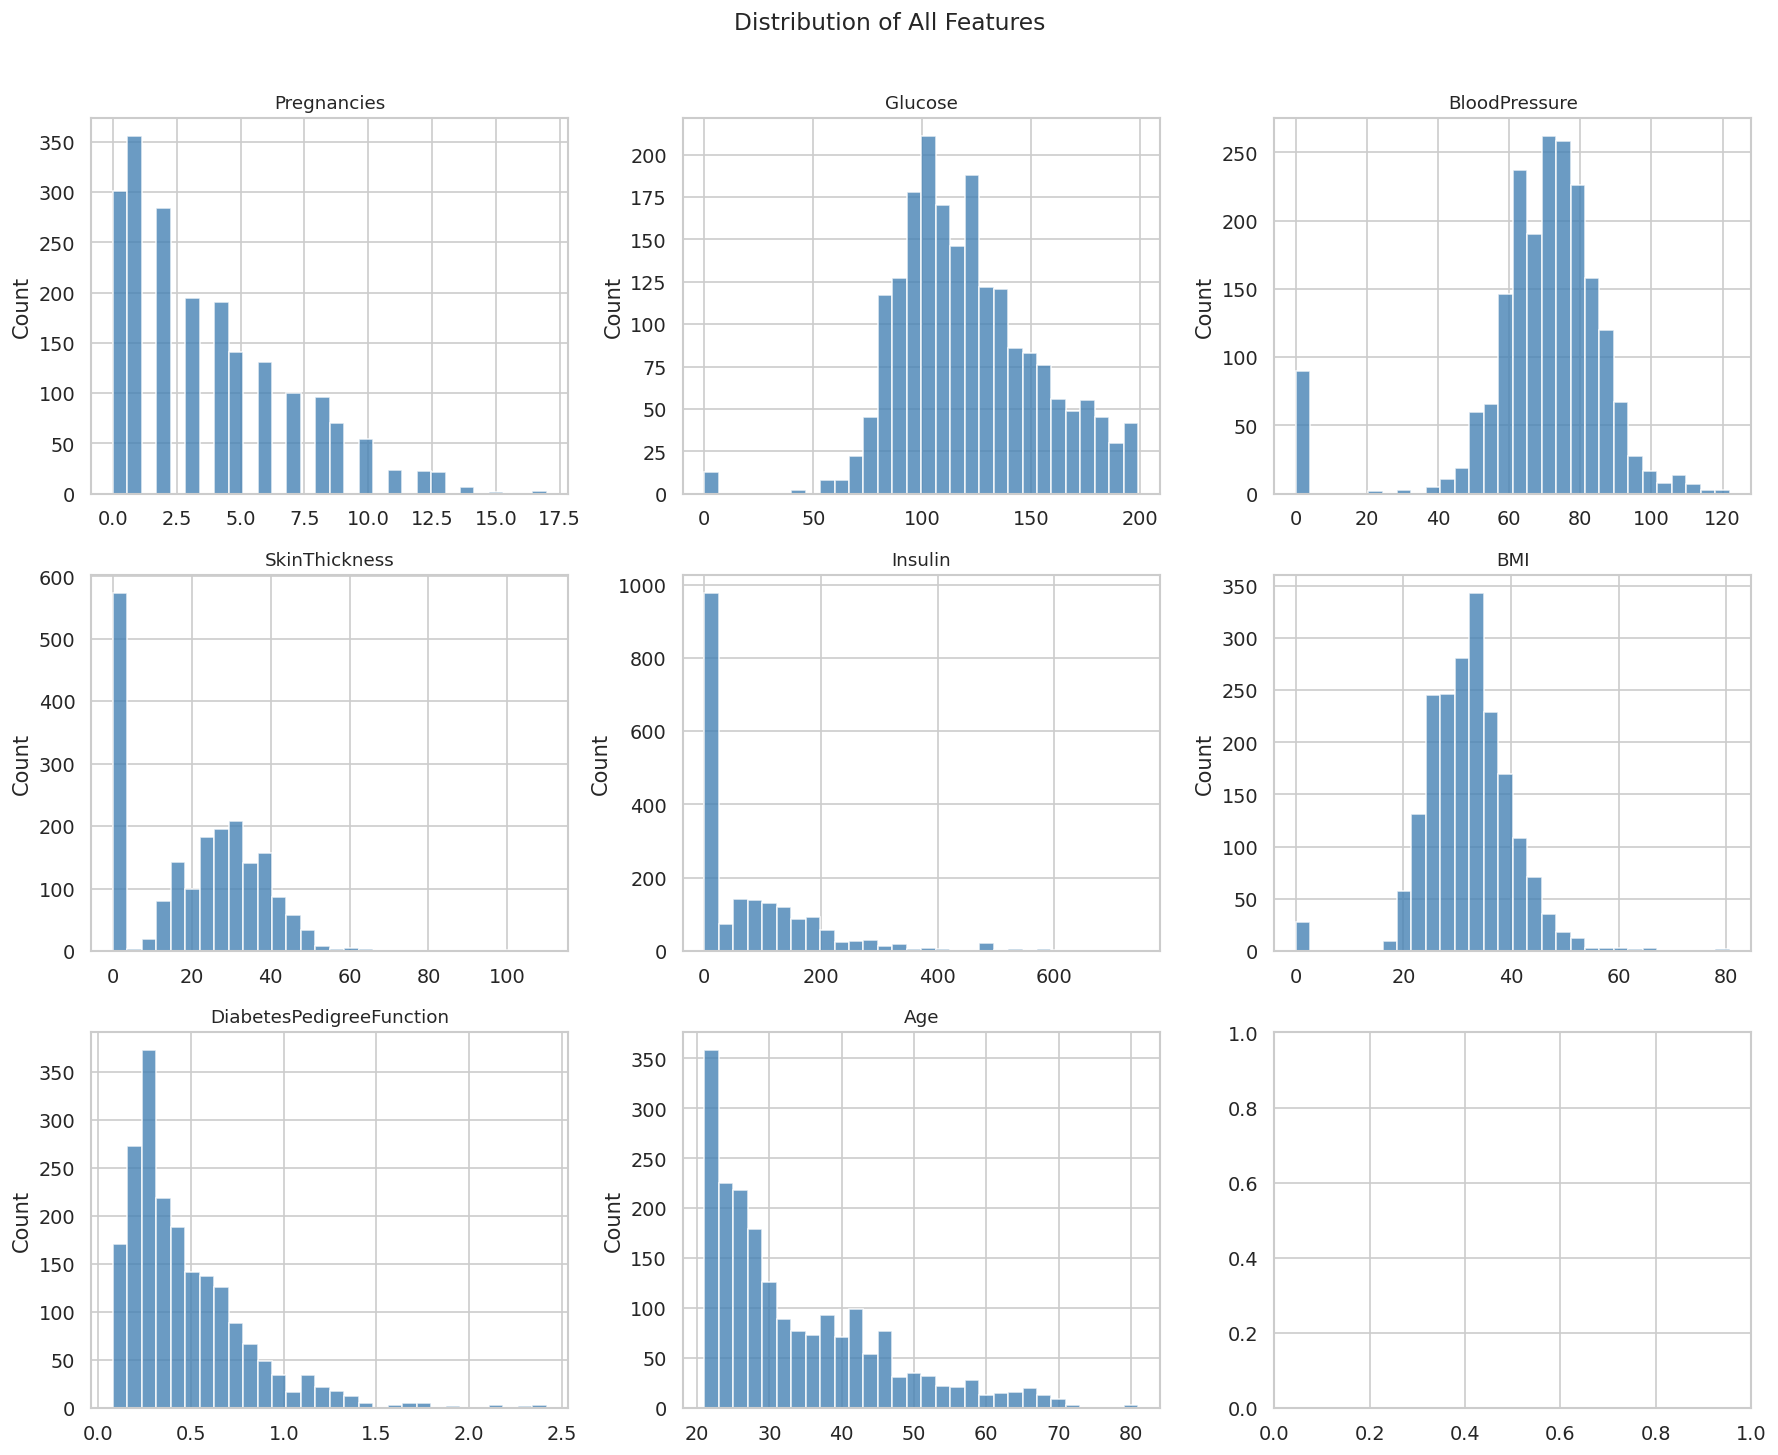

💡 Notice the spike at 0 in Glucose, BloodPressure, SkinThickness,
   Insulin, and BMI — these are the missing values coded as zeros.


In [ ]:
# ── Distribution of all features ──
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), features.columns):
    diabetes_data[col].hist(bins=30, ax=ax, edgecolor='white', alpha=0.8, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Count')
fig.suptitle('Distribution of All Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Notice the spike at 0 in Glucose, BloodPressure, SkinThickness,")
print("   Insulin, and BMI — these are the missing values coded as zeros.")


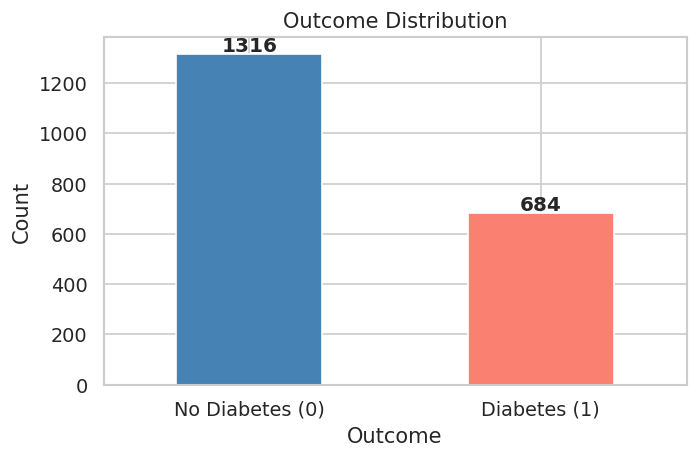

Class balance: 1316 non-diabetic (65.8%) vs 684 diabetic (34.2%)
💡 Moderate imbalance — accuracy alone may be misleading.
   We should also track precision, recall, and F1-score.


In [ ]:
# ── Outcome class balance ──
fig, ax = plt.subplots(figsize=(6, 4))
diabetes_data['Outcome'].value_counts().sort_index().plot.bar(
    ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Outcome Distribution')
for i, v in enumerate(diabetes_data['Outcome'].value_counts().sort_index()):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class balance: {(target==0).sum()} non-diabetic ({(target==0).mean():.1%}) vs "
      f"{(target==1).sum()} diabetic ({(target==1).mean():.1%})")
print("💡 Moderate imbalance — accuracy alone may be misleading.")
print("   We should also track precision, recall, and F1-score.")


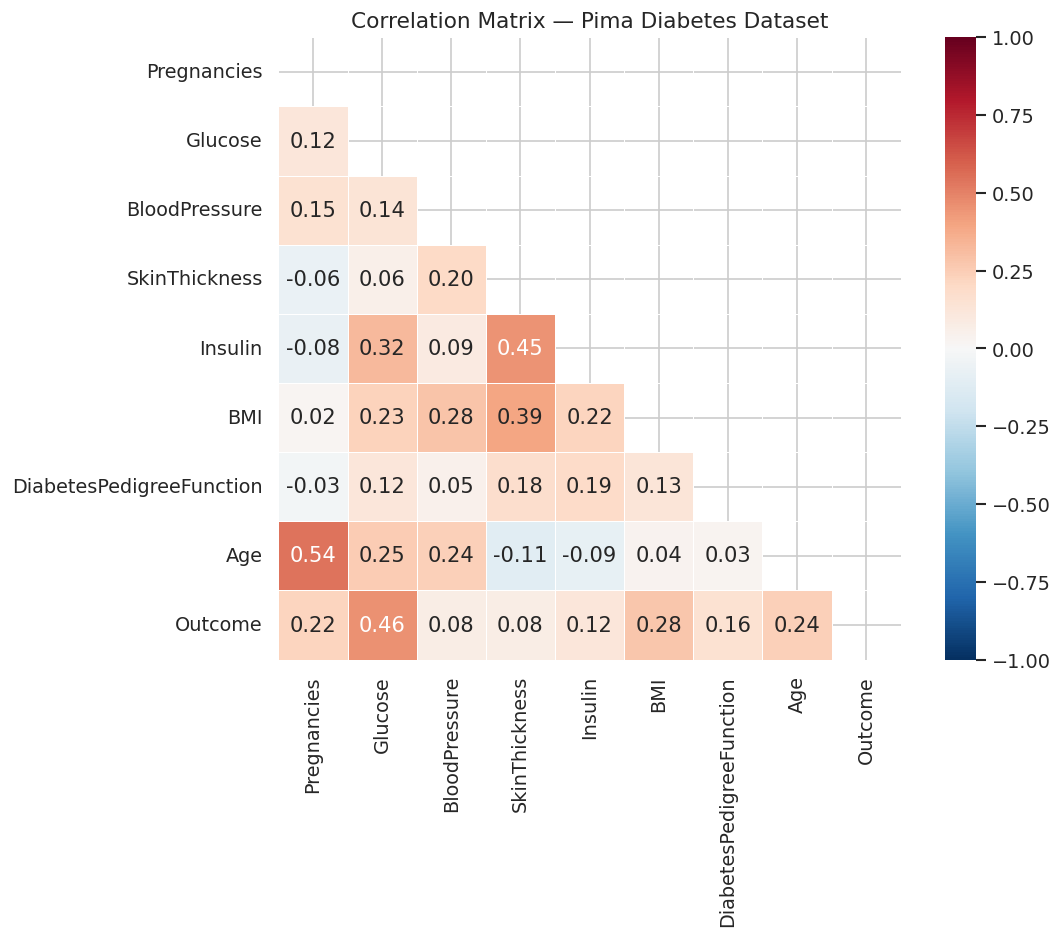

💡 Key observations:
   • Glucose has the strongest correlation with Outcome (diabetes)
   • Age and Pregnancies are correlated (older patients have had more pregnancies)
   • BMI and SkinThickness are correlated (both measure body fat)


In [ ]:
# ── Correlation heatmap ──
fig, ax = plt.subplots(figsize=(10, 8))
corr = diabetes_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Pima Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print("💡 Key observations:")
print("   • Glucose has the strongest correlation with Outcome (diabetes)")
print("   • Age and Pregnancies are correlated (older patients have had more pregnancies)")
print("   • BMI and SkinThickness are correlated (both measure body fat)")


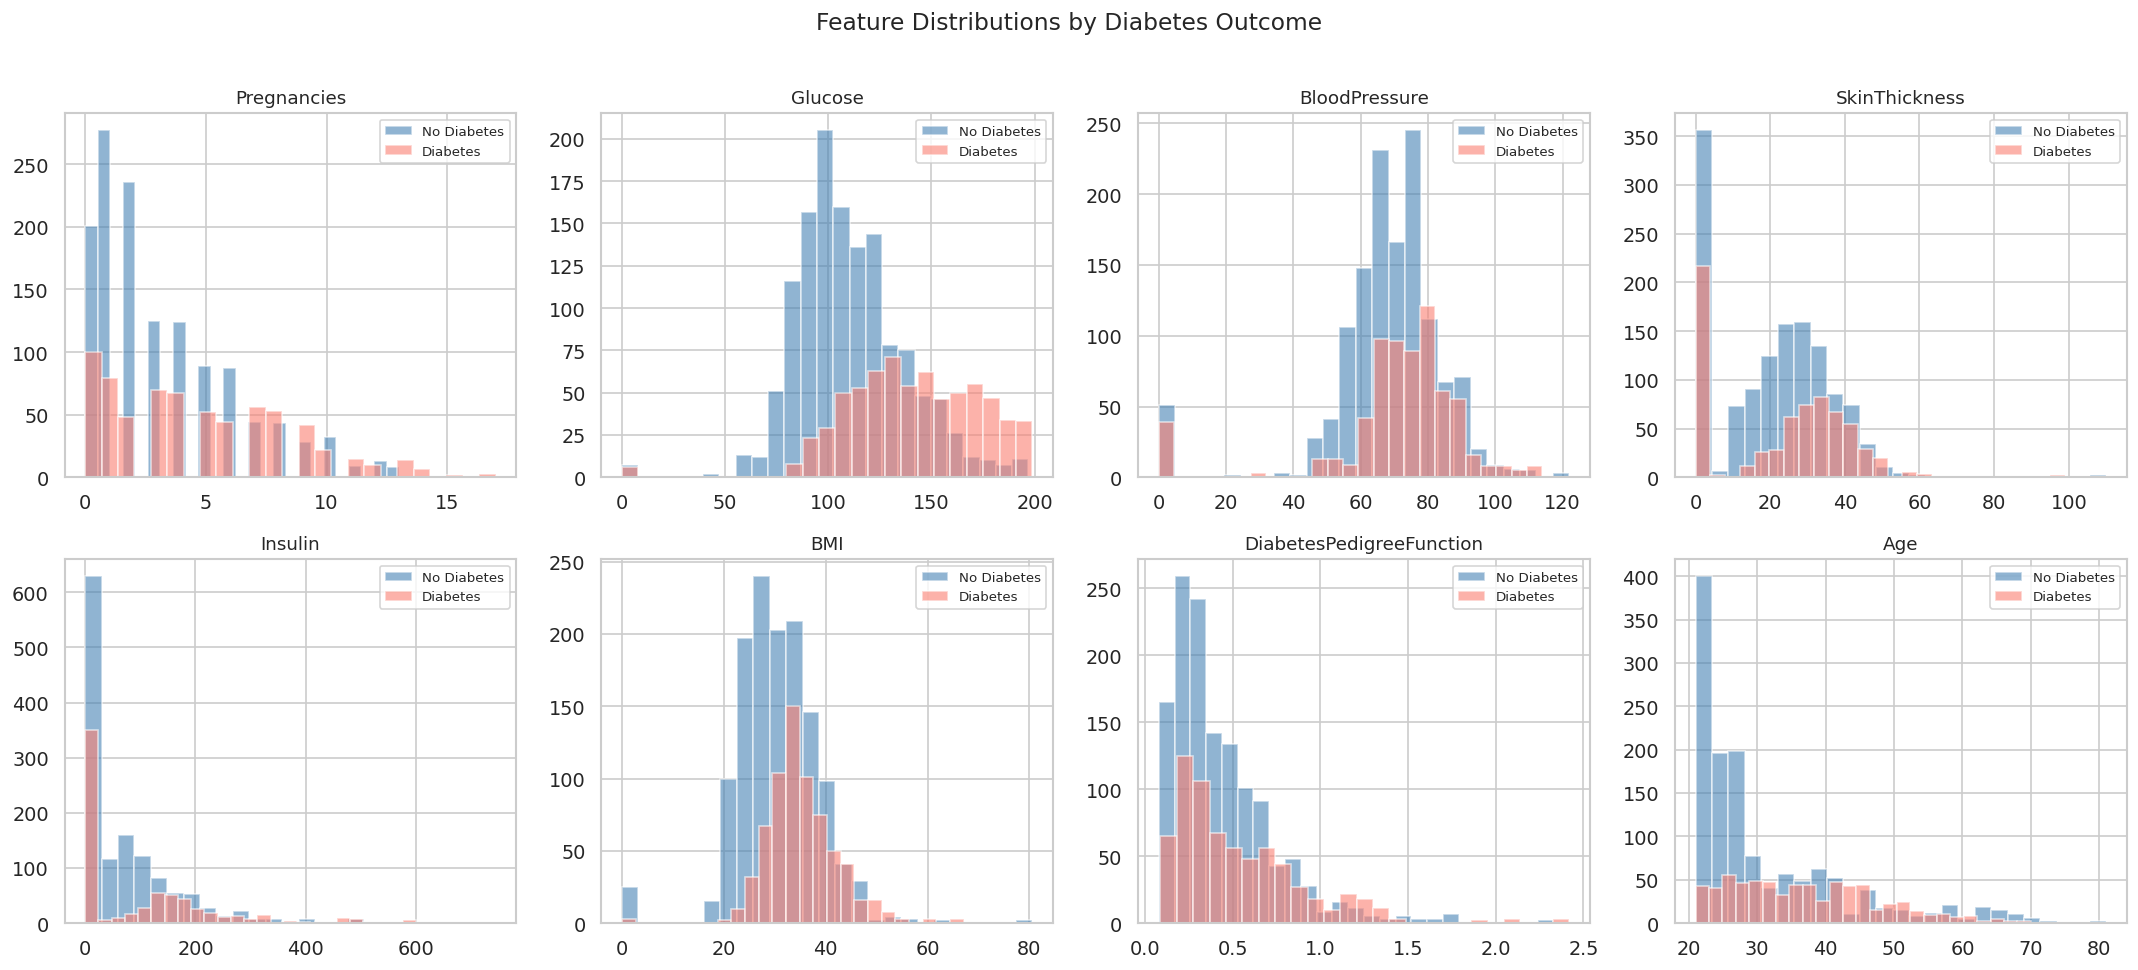

💡 Glucose, BMI, and Age show the clearest separation between groups —
   consistent with established clinical risk factors for Type 2 diabetes.


In [ ]:
# ── Feature distributions by outcome ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), features.columns):
    diabetes_data[diabetes_data['Outcome'] == 0][col].hist(
        bins=25, ax=ax, alpha=0.6, color='steelblue', label='No Diabetes', edgecolor='white')
    diabetes_data[diabetes_data['Outcome'] == 1][col].hist(
        bins=25, ax=ax, alpha=0.6, color='salmon', label='Diabetes', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)
fig.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Glucose, BMI, and Age show the clearest separation between groups —")
print("   consistent with established clinical risk factors for Type 2 diabetes.")


---

# Module 2: Supervised Learning — Linear and Logistic Regression

---

## 2.1 What Is Supervised Learning?

In supervised learning, we have a dataset where the **correct answer (label) is known** for each example, and we train an algorithm to learn the mapping from inputs to outputs. The word "supervised" comes from the idea that the correct answers "supervise" the learning process — like a teacher grading homework.

**Two types of supervised learning:**

| | **Regression** | **Classification** |
|---|---|---|
| **Target type** | Continuous (numbers) | Categorical (classes) |
| **Clinical examples** | Predict blood pressure, predict HbA1c, predict hospital length of stay | Predict diabetes yes/no, predict malignant vs. benign tumour, predict readmission |
| **Algorithm examples** | Linear regression, Ridge, Lasso | Logistic regression, Decision tree, Random forest |
| **Evaluation metrics** | MSE, RMSE, R², MAE | Accuracy, Precision, Recall, F1, AUC-ROC |

In this module, we cover:
- **Linear Regression** — predicting a continuous outcome
- **Logistic Regression** — predicting a binary outcome (diabetes yes/no)
- **Decision Trees and Random Forests** — more flexible classification methods
- **Cross-Validation** — robust model evaluation

---

## 2.2 Linear Regression

### Definition
Linear regression is a supervised learning algorithm that predicts a **continuous numerical outcome** by fitting a straight line (or hyperplane in multiple dimensions) to the data. It assumes a **linear relationship** between the input features and the target variable.

### The Mathematical Model
The relationship is modelled using the equation:

**y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ**

Where:
- **y** is the predicted outcome (e.g., blood pressure)
- **β₀** is the intercept — the predicted value when all features are zero
- **β₁, β₂, ..., βₙ** are the coefficients (slopes) — each tells you how much the outcome changes per one-unit increase in that feature, holding all other features constant
- **x₁, x₂, ..., xₙ** are the input features (e.g., glucose, BMI, age)

This is the same equation as **y = mx + b** from algebra, extended to multiple variables.

### How It Learns
The algorithm finds the coefficients that **minimise the sum of squared residuals** (Ordinary Least Squares):
- A residual = actual value − predicted value
- Squaring ensures positive and negative errors don't cancel out
- The algorithm finds the line that minimises the total squared distance from all data points to the line

### Key Assumptions
1. **Linearity:** The relationship between features and target is approximately linear
2. **Independence:** Observations are independent of each other
3. **Homoscedasticity:** The variance of residuals is constant across all predicted values
4. **Normality of residuals:** Residuals are approximately normally distributed (important for statistical inference, less so for prediction)

### Evaluation Metrics

| Metric | Formula Intuition | Clinical Meaning |
|--------|-------------------|-----------------|
| **MSE** (Mean Squared Error) | Average of (actual − predicted)² | Penalises large errors heavily; units are squared |
| **RMSE** (Root MSE) | √MSE | Error in the same units as the target — "on average, the prediction is off by X" |
| **R²** (R-squared) | 1 − (unexplained variance / total variance) | Proportion of variance explained; 0 = no better than predicting the mean; 1 = perfect |
| **MAE** (Mean Absolute Error) | Average of |actual − predicted| | Average error magnitude, robust to outliers |

### Clinical Example
If we wanted to predict a patient's blood pressure from their glucose, BMI, and age, linear regression would learn coefficients like: "each 1 mg/dL increase in glucose is associated with a 0.15 mmHg increase in blood pressure, adjusted for BMI and age."

### ⚠️ Important Note for This Dataset
Our diabetes dataset has a **binary target** (Outcome: 0 or 1). Linear regression is technically designed for continuous targets. We demonstrate it here for educational purposes to show what happens when you apply regression to a classification problem, and why logistic regression is the correct choice.


In [ ]:
# ══════════════════════════════════════════════
# LINEAR REGRESSION EXAMPLE
# ══════════════════════════════════════════════
# Using Glucose, BMI, and Age to predict Outcome (for demonstration)

X = features[['Glucose', 'BMI', 'Age']]
y = target

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train_lr, y_train_lr)

# Predict and evaluate
y_pred_lr = lin_reg.predict(X_test_lr)
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_lr, y_pred_lr)
mae = mean_absolute_error(y_test_lr, y_pred_lr)

print("═" * 55)
print("  LINEAR REGRESSION — Predicting Diabetes Outcome")
print("═" * 55)
print(f"  Mean Squared Error (MSE)  : {mse:.4f}")
print(f"  Root Mean Squared Error   : {rmse:.4f}")
print(f"  Mean Absolute Error (MAE) : {mae:.4f}")
print(f"  R-Squared (R²)           : {r2:.4f}")
print("═" * 55)

# Show coefficients
print("\n── Learned Coefficients ──")
for feat, coef in zip(['Glucose', 'BMI', 'Age'], lin_reg.coef_):
    print(f"  {feat:12s}: {coef:+.4f}")
print(f"  {'Intercept':12s}: {lin_reg.intercept_:+.4f}")

print(f"\n💡 R² = {r2:.2f} — the model explains only {r2:.0%} of the variance.")
print("   This is expected: we are using linear regression for a binary outcome.")
print("   The predictions are continuous (e.g., 0.37) rather than 0 or 1.")
print("   ➡️  For binary classification, we need LOGISTIC regression (next section).")


═══════════════════════════════════════════════════════
  LINEAR REGRESSION — Predicting Diabetes Outcome
═══════════════════════════════════════════════════════
  Mean Squared Error (MSE)  : 0.1731
  Root Mean Squared Error   : 0.4161
  Mean Absolute Error (MAE) : 0.3547
  R-Squared (R²)           : 0.2552
═══════════════════════════════════════════════════════

── Learned Coefficients ──
  Glucose     : +0.0054
  BMI         : +0.0115
  Age         : +0.0056
  Intercept   : -0.8769

💡 R² = 0.26 — the model explains only 26% of the variance.
   This is expected: we are using linear regression for a binary outcome.
   The predictions are continuous (e.g., 0.37) rather than 0 or 1.
   ➡️  For binary classification, we need LOGISTIC regression (next section).


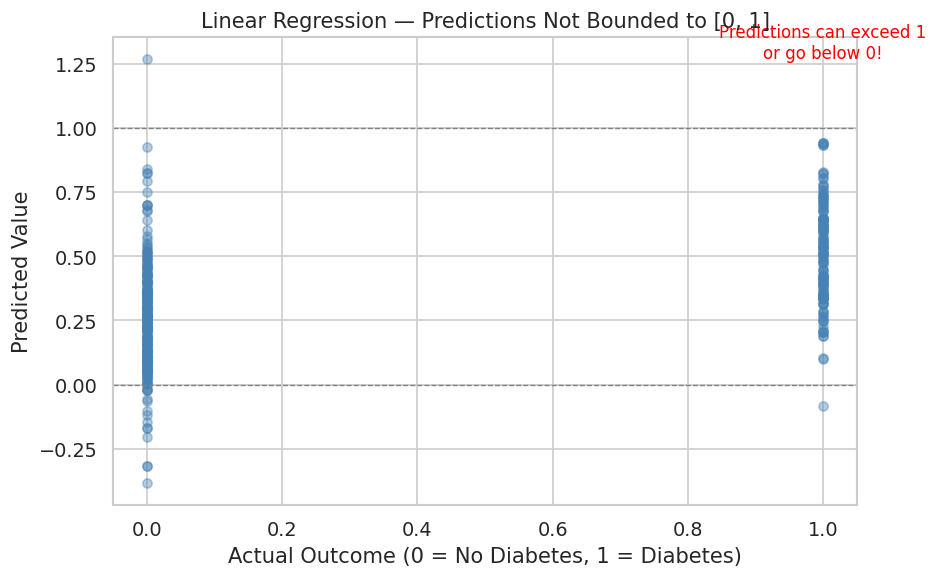

⚠️  This is why linear regression is inappropriate for binary classification —
   predicted values should represent probabilities (bounded between 0 and 1).


In [ ]:
# ── Visualise: Predicted values are NOT bounded to [0, 1] ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test_lr, y_pred_lr, alpha=0.4, s=30, color='steelblue')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(1, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Actual Outcome (0 = No Diabetes, 1 = Diabetes)')
ax.set_ylabel('Predicted Value')
ax.set_title('Linear Regression — Predictions Not Bounded to [0, 1]')
ax.annotate('Predictions can exceed 1\nor go below 0!',
            xy=(1, max(y_pred_lr)), fontsize=10, color='red',
            ha='center')
plt.tight_layout()
plt.show()

print("⚠️  This is why linear regression is inappropriate for binary classification —")
print("   predicted values should represent probabilities (bounded between 0 and 1).")


**Note**: R² = 0.26, the model explains only 26% of the variance, and predictions are continuous values (e.g., 0.37) rather than clean 0/1 classifications. This is the expected result and demonstrates exactly why linear regression is the wrong tool for a binary classification problem. The scatter plot would show predictions spilling outside the [0, 1] range, which is meaningless as a probability. This cell serves as a pedagogical contrast to motivate logistic regression.


---

## 2.3 Logistic Regression

### Definition
Logistic regression is a supervised learning algorithm designed for **binary classification**, predicting which of two categories an observation belongs to (e.g., diabetic or non-diabetic). Despite its name, it is a **classification** algorithm, not a regression algorithm.

### The Mathematical Model
Instead of fitting a straight line, logistic regression passes the linear equation through the **sigmoid (logistic) function**, which squeezes any real number into the range [0, 1]:

**P(Y=1|X) = 1 / (1 + e^-(β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ))**

Where:
- **P(Y=1|X)** is the probability that the patient has diabetes, given their feature values
- The sigmoid function ensures the output is always between 0 and 1, interpretable as a probability
- If P ≥ 0.5, we classify as diabetic (1); if P < 0.5, we classify as non-diabetic (0)
- The threshold of 0.5 is the default, but can be adjusted depending on clinical priorities

### Interpreting Coefficients as Odds Ratios
One of the powerful features of logistic regression for medical use is that the coefficients have a direct clinical interpretation:

- **e^β** gives the **odds ratio** for that feature
- **OR > 1:** Each unit increase in the feature **increases** the odds of diabetes
- **OR < 1:** Each unit increase in the feature **decreases** the odds of diabetes
- **OR = 1:** The feature has no effect on the odds

For example, if β₁ = 0.035 for Glucose, then OR = e^0.035 ≈ 1.036, meaning each 1 mg/dL increase in glucose increases the odds of diabetes by about 3.6%.

### Evaluation Metrics for Classification

**Confusion Matrix**: the foundation of all classification metrics:

|  | Predicted: No Diabetes | Predicted: Diabetes |
|--|----------------------|-------------------|
| **Actual: No Diabetes** | True Negative (TN) | False Positive (FP) |
| **Actual: Diabetes** | False Negative (FN) | True Positive (TP) |

From this matrix, we derive:

| Metric | Formula | Clinical Meaning | When to Prioritise |
|--------|---------|-----------------|-------------------|
| **Accuracy** | (TP+TN) / Total | Overall proportion correct | General performance, but misleading with imbalanced data |
| **Precision (PPV)** | TP / (TP+FP) | "When the model says diabetes, how often is it right?" | When false positives are costly (e.g., unnecessary invasive procedures, expensive treatments with side effects) |
| **Recall (Sensitivity)** | TP / (TP+FN) | "Of all actual diabetics, how many does the model catch?" | When missing a case is dangerous (e.g., screening programs: you want to catch every diabetic patient) |
| **Specificity** | TN / (TN+FP) | "Of all non-diabetics, how many are correctly ruled out?" | When false alarms overwhelm the system |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean balancing precision and recall | When both false positives and false negatives matter, especially with imbalanced datasets |

### Precision vs. Recall:  A Clinical Decision

This is one of the most important concepts in medical ML. The choice depends on the **clinical context**:

**Prioritise Recall (Sensitivity) when:**
- Missing a positive case has severe consequences
- Example: Cancer screening: you want to catch every cancer, even if it means some healthy people get further (non-invasive) testing
- Example: Diabetes screening in a population, undiagnosed diabetes leads to serious complications (retinopathy, nephropathy, neuropathy)

**Prioritise Precision when:**
- A false positive leads to significant harm or cost
- Example: Recommending surgery: you want to be very confident the diagnosis is correct before an invasive procedure
- Example: Prescribing a medication with serious side effects: a false positive means unnecessary exposure to toxicity

**Use F1-Score when:**
- Both types of errors matter, or the dataset is imbalanced
- Example: General diabetes prediction where both false positives (unnecessary anxiety, testing) and false negatives (missed diagnoses) are undesirable

---


In [ ]:
# ══════════════════════════════════════════════
# LOGISTIC REGRESSION — Diabetes Classification
# ══════════════════════════════════════════════

X = features[['Glucose', 'BMI', 'Age']]
y = target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)

# Predict
y_pred_c = log_reg.predict(X_test_c)
y_prob_c = log_reg.predict_proba(X_test_c)[:, 1]  # Probability of class 1

# Evaluate
conf_matrix = confusion_matrix(y_test_c, y_pred_c)
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("═" * 55)
print("  LOGISTIC REGRESSION — Diabetes Prediction")
print("═" * 55)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("═" * 55)


═══════════════════════════════════════════════════════
  LOGISTIC REGRESSION — Diabetes Prediction
═══════════════════════════════════════════════════════
  Accuracy  : 0.8025
  Precision : 0.7685
  Recall    : 0.6058
  F1-Score  : 0.6776
═══════════════════════════════════════════════════════


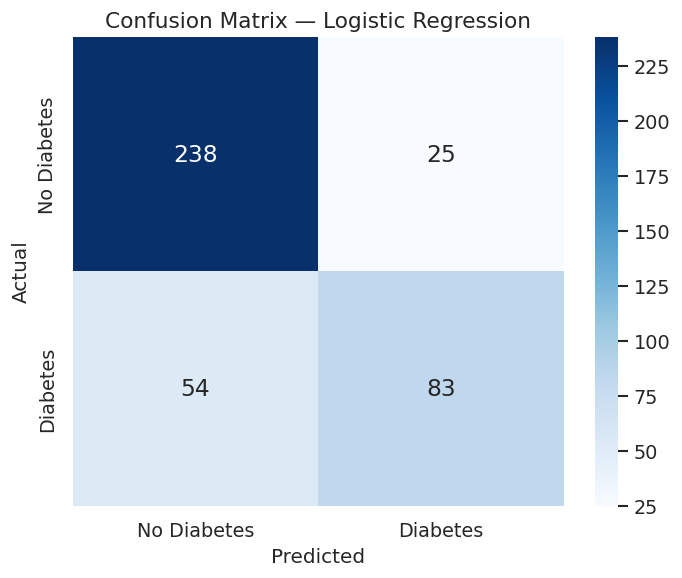

── Confusion Matrix Breakdown ──
  True Negatives  (correctly ruled out):      238
  False Positives (false alarms):             25
  False Negatives (MISSED diabetics):         54
  True Positives  (correctly identified):     83

💡 54 patients with diabetes were MISSED in a screening context,
   these are the most concerning errors.


In [ ]:
# ── Confusion Matrix Visualisation ──
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = conf_matrix.ravel()
print("── Confusion Matrix Breakdown ──")
print(f"  True Negatives  (correctly ruled out):      {tn}")
print(f"  False Positives (false alarms):             {fp}")
print(f"  False Negatives (MISSED diabetics):         {fn}")
print(f"  True Positives  (correctly identified):     {tp}")
print(f"\n💡 {fn} patients with diabetes were MISSED in a screening context,")
print(f"   these are the most concerning errors.")


In [ ]:
# ── Detailed Classification Report ──
print("── Full Classification Report ──\n")
print(classification_report(y_test_c, y_pred_c,
                            target_names=['No Diabetes', 'Diabetes']))


── Full Classification Report ──

              precision    recall  f1-score   support

 No Diabetes       0.82      0.90      0.86       263
    Diabetes       0.77      0.61      0.68       137

    accuracy                           0.80       400
   macro avg       0.79      0.76      0.77       400
weighted avg       0.80      0.80      0.80       400



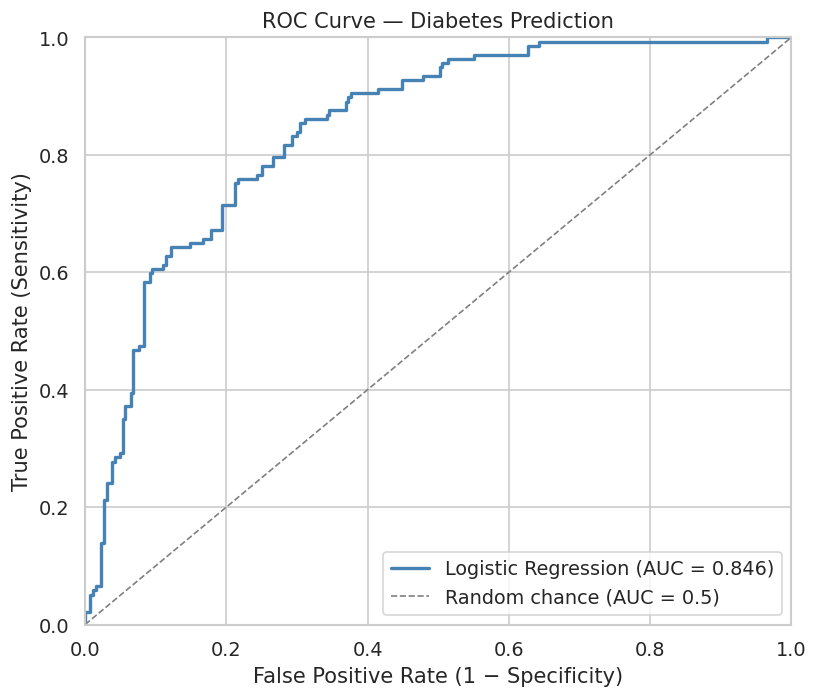

💡 AUC = 0.846
   Interpretation: If you pick one random diabetic and one random non-diabetic
   patient, the model correctly ranks them 85% of the time.
   AUC 0.5 = random chance | 0.7–0.8 = acceptable | 0.8–0.9 = excellent | > 0.9 = outstanding


In [ ]:
# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
auc_val = roc_auc_score(y_test_c, y_prob_c)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, 'steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1, label='Random chance (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Diabetes Prediction')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"💡 AUC = {auc_val:.3f}")
print("   Interpretation: If you pick one random diabetic and one random non-diabetic")
print(f"   patient, the model correctly ranks them {auc_val:.0%} of the time.")
print("   AUC 0.5 = random chance | 0.7–0.8 = acceptable | 0.8–0.9 = excellent | > 0.9 = outstanding")


In [ ]:
# ── Odds Ratios ──
or_df = pd.DataFrame({
    'Feature': ['Glucose', 'BMI', 'Age'],
    'Coefficient (β)': log_reg.coef_[0],
    'Odds Ratio (eᵝ)': np.exp(log_reg.coef_[0])
}).sort_values('Odds Ratio (eᵝ)', ascending=False).reset_index(drop=True)

print("── Odds Ratios ──\n")
print(or_df.to_string(index=False))
print("\n💡 Interpretation:")
print("   OR > 1: each unit increase raises diabetes odds")
print("   OR < 1: each unit increase lowers diabetes odds")
print("   e.g., Glucose OR ≈ 1.04 means each 1 mg/dL increase in glucose")
print("   raises the odds of diabetes by ~4%.")


── Odds Ratios ──

Feature  Coefficient (β)  Odds Ratio (eᵝ)
    BMI         0.075859         1.078811
Glucose         0.030108         1.030566
    Age         0.026485         1.026839

💡 Interpretation:
   OR > 1: each unit increase raises diabetes odds
   OR < 1: each unit increase lowers diabetes odds
   e.g., Glucose OR ≈ 1.04 means each 1 mg/dL increase in glucose
   raises the odds of diabetes by ~4%.


**Note**: Odds ratios: BMI has the highest OR at 1.079 (each 1 kg/m² increase → 7.9% higher odds), followed by Glucose at 1.031 (each 1 mg/dL → 3.1% higher odds), and Age at 1.027. These are per-unit increases on the raw scale. The reason BMI's OR looks larger is that a 1-unit change in BMI is a bigger physiological shift than 1 mg/dL of glucose.


### 2.3.1 Cross-Validation

A single train/test split can be "lucky" or "unlucky", the test set might happen to contain easier or harder cases. **Cross-validation** provides a more robust and reliable performance estimate.

**How K-Fold Cross-Validation Works:**
1. Divide the entire dataset into K equally sized "folds" (typically K = 5 or 10)
2. For each fold:
   - Use that fold as the test set
   - Use the remaining K−1 folds as the training set
   - Train the model and record the performance
3. Report the **mean and standard deviation** of performance across all folds

**Stratified K-Fold** ensures that each fold has the same proportion of diabetic and non-diabetic patients as the full dataset — essential when classes are imbalanced.

**Why is this better than a single split?**
- Every patient gets to be in the test set exactly once
- The mean score is a more reliable estimate of true performance
- The standard deviation tells you how stable the model is
- Reduces the risk of reporting an overly optimistic or pessimistic result


In [ ]:
# ── 5-Fold Stratified Cross-Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=cv, scoring='accuracy')

print("═" * 55)
print("  5-FOLD CROSS-VALIDATION Logistic Regression")
print("═" * 55)
for i, score in enumerate(cv_accuracy, 1):
    bar = "█" * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")
print(f"\n  Mean Accuracy : {cv_accuracy.mean():.4f}")
print(f"  Std Deviation : {cv_accuracy.std():.4f}")
print("═" * 55)
print("\n💡 The low standard deviation across folds indicates stable performance.")
print("   Always report mean ± std in publications, not a single test-set number.")


═══════════════════════════════════════════════════════
  5-FOLD CROSS-VALIDATION Logistic Regression
═══════════════════════════════════════════════════════
  Fold 1: 0.7525  ██████████████████████████████
  Fold 2: 0.7600  ██████████████████████████████
  Fold 3: 0.7675  ██████████████████████████████
  Fold 4: 0.7925  ███████████████████████████████
  Fold 5: 0.7700  ██████████████████████████████

  Mean Accuracy : 0.7685
  Std Deviation : 0.0135
═══════════════════════════════════════════════════════

💡 The low standard deviation across folds indicates stable performance.
   Always report mean ± std in publications, not a single test-set number.


---

## 2.4 Decision Trees

### Definition
A Decision Tree is a supervised learning algorithm that makes predictions by asking a series of yes/no questions about the features, creating a tree-like flowchart of decisions.

**Clinical analogy:** Think of a clinical decision algorithm — "Is the patient's glucose ≥ 200 mg/dL? If yes, check BMI. If BMI ≥ 30, classify as high risk..."  Decision trees formalise and optimise this process.

### How Decision Trees Work
1. **Start at the root node** with the entire dataset
2. **Select the best feature and threshold** to split the data, using criteria such as:
   - **Gini Impurity:** Measures how often a randomly chosen element would be incorrectly classified (lower = purer nodes)
   - **Entropy (Information Gain):** Measures the reduction in uncertainty after a split (higher gain = better split)
3. **Repeat recursively** for each branch until a stopping criterion is met (max depth, minimum samples per leaf, or pure nodes)

### Key Hyperparameters
| Parameter | Description | Effect |
|-----------|-------------|--------|
| `criterion` | 'gini' or 'entropy' | How splits are chosen; gini is faster, entropy sometimes more accurate |
| `max_depth` | Maximum tree depth | Controls complexity — deeper = more flexible but higher overfitting risk |
| `min_samples_split` | Minimum samples to split a node | Higher values prevent overfitting |
| `min_samples_leaf` | Minimum samples in a leaf | Prevents very small, noisy groups |

### Advantages
- Easy to interpret and visualise — you can trace exactly why a prediction was made
- Handles both numerical and categorical data without scaling
- Captures non-linear relationships naturally
- No feature scaling required

### Disadvantages
- **Prone to overfitting** — a deep tree can memorise the training data perfectly but fail on new patients
- **Unstable** — small changes in data can produce very different trees
- Not ideal for very large datasets alone → use ensemble methods (Random Forest)


In [ ]:
# ══════════════════════════════════════════════
# DECISION TREE — Diabetes Classification
# ══════════════════════════════════════════════

X = features[['Glucose', 'BMI', 'Age']]
y = target

clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(clf, X, y, cv=cv, scoring='precision')
cv_recall = cross_val_score(clf, X, y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(clf, X, y, cv=cv, scoring='f1')

# Cross-validation predictions for confusion matrix
y_pred_cv = cross_val_predict(clf, X, y, cv=cv)
conf_matrix_dt = confusion_matrix(y, y_pred_cv)

print("═" * 55)
print("  DECISION TREE 5-Fold Cross-Validation Results")
print("═" * 55)
print(f"  Mean Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"  Mean Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  Mean Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  Mean F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print("═" * 55)

print("\n── Confusion Matrix (aggregated from all CV folds) ──")
print(conf_matrix_dt)
print("\n── Classification Report ──")
print(classification_report(y, y_pred_cv, target_names=['No Diabetes', 'Diabetes']))


═══════════════════════════════════════════════════════
  DECISION TREE 5-Fold Cross-Validation Results
═══════════════════════════════════════════════════════
  Mean Accuracy  : 0.7965 ± 0.0224
  Mean Precision : 0.6975 ± 0.0350
  Mean Recall    : 0.7164 ± 0.0311
  Mean F1-Score  : 0.7067 ± 0.0312
═══════════════════════════════════════════════════════

── Confusion Matrix (aggregated from all CV folds) ──
[[1103  213]
 [ 194  490]]

── Classification Report ──
              precision    recall  f1-score   support

 No Diabetes       0.85      0.84      0.84      1316
    Diabetes       0.70      0.72      0.71       684

    accuracy                           0.80      2000
   macro avg       0.77      0.78      0.78      2000
weighted avg       0.80      0.80      0.80      2000



**Note**: The key difference from logistic regression: the Decision Tree has substantially better recall (71.6% vs. 55.7%). It catches more diabetic patients. The trade-off is lower precision (69.8% vs. 70.4%). If your priority is screening (don't miss anyone), the Decision Tree is doing better here. 213 false positives and 194 false negatives, meaning more balanced between the two error types than logistic regression.


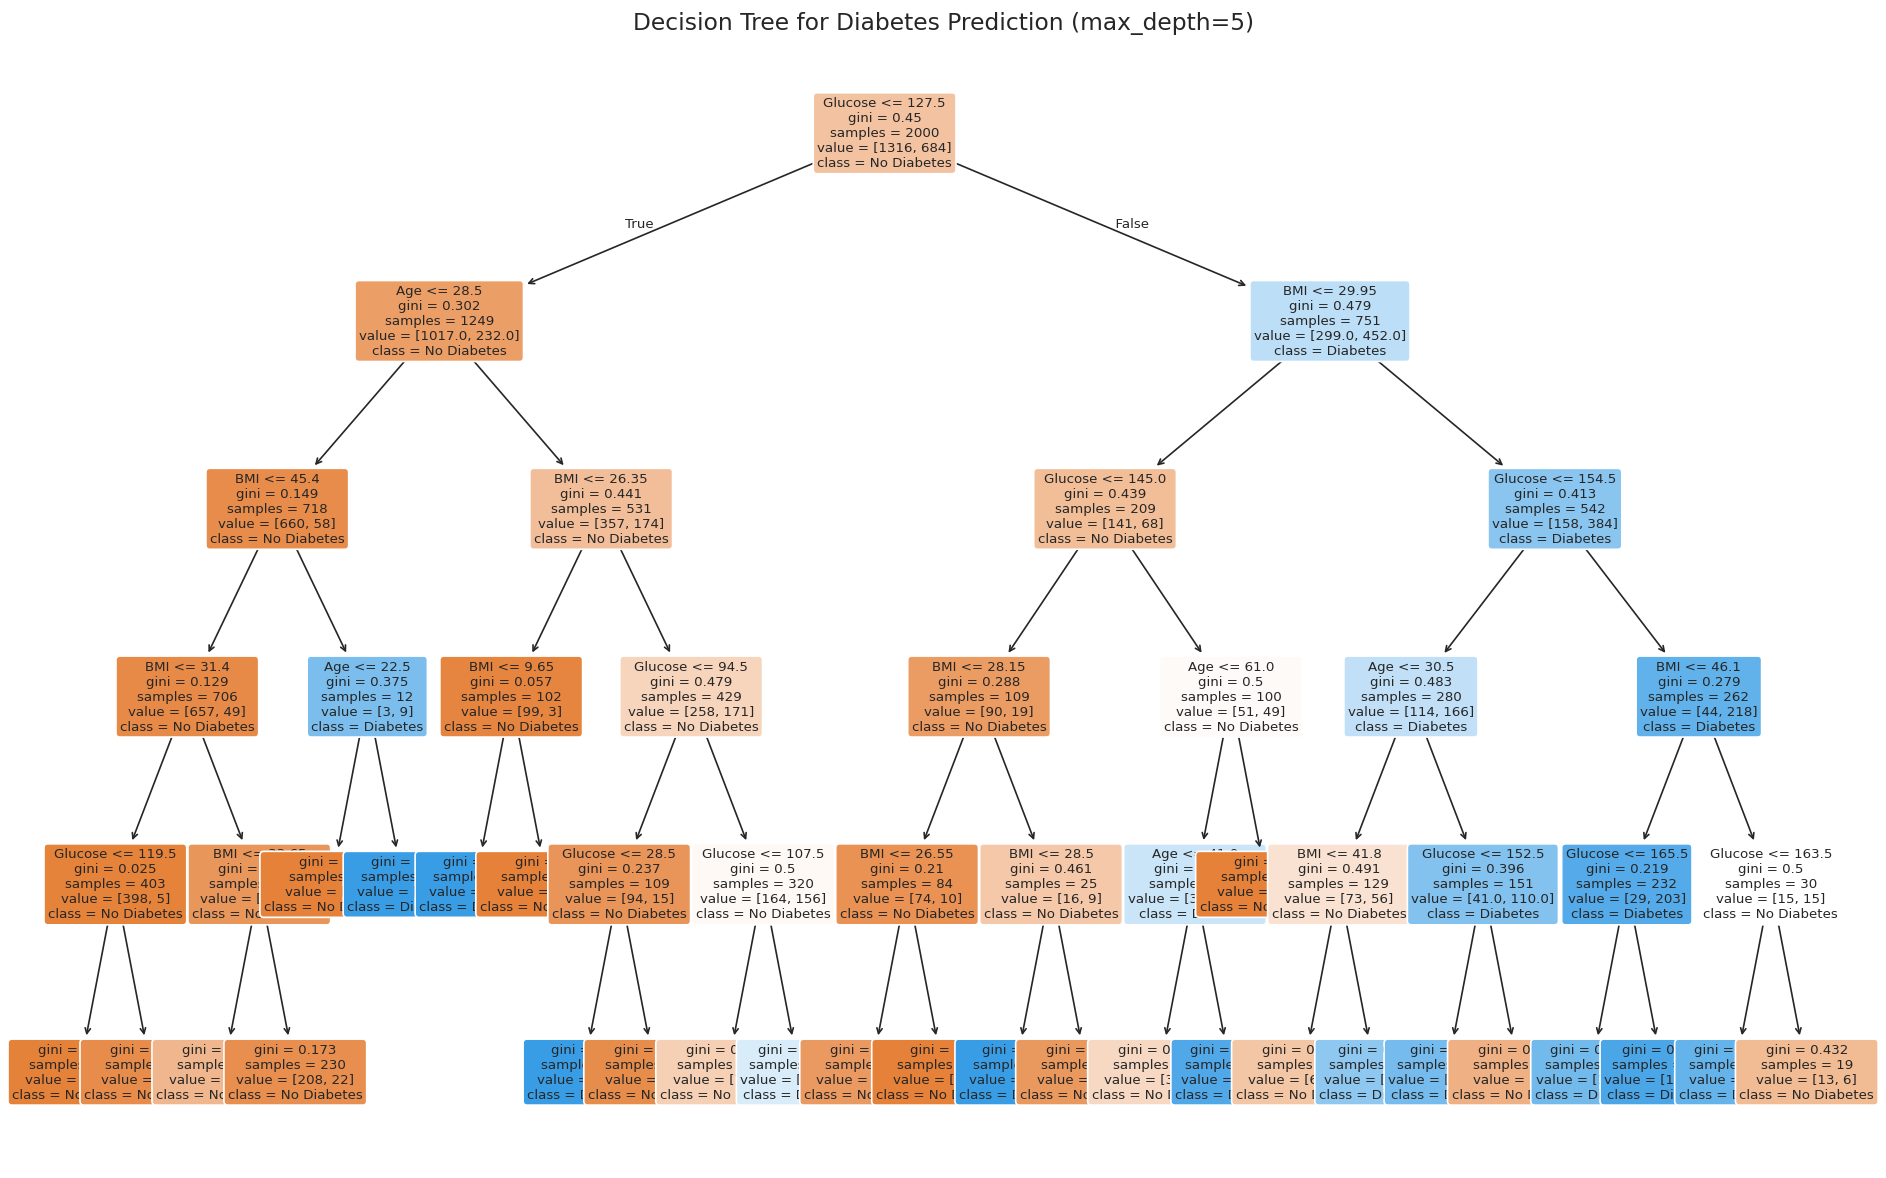

💡 Reading the tree: Each node shows the feature and threshold used to split,
   the Gini impurity, the number of samples, and the majority class.
   Follow any branch from root to leaf to see the decision path for a patient.


In [ ]:
# ── Visualise the Decision Tree ──
clf.fit(X, y)
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(clf, feature_names=['Glucose', 'BMI', 'Age'],
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree for Diabetes Prediction (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Reading the tree: Each node shows the feature and threshold used to split,")
print("   the Gini impurity, the number of samples, and the majority class.")
print("   Follow any branch from root to leaf to see the decision path for a patient.")


---

## 2.5 Random Forest

### Definition
Random Forest is an **ensemble learning** method that builds many Decision Trees and combines their predictions. It is one of the most popular and effective ML algorithms across all domains, including medicine.

### How It Works
1. **Bootstrap Sampling (Bagging):** Create multiple random subsets of the training data (sampling with replacement). Each subset trains a separate Decision Tree.
2. **Feature Randomisation:** At each split in each tree, only consider a random subset of features. This forces the trees to be diverse.
3. **Aggregation:**
   - For classification: **Majority voting**: each tree "votes" and the most popular class wins
   - For regression: **Averaging**: the predicted value is the mean of all trees' predictions

### Why Is Random Forest Better Than a Single Tree?
- **Reduces overfitting:** Individual trees may overfit, but averaging many diverse trees smooths out the noise
- **More stable:** Small changes in data won't dramatically change the result
- **Handles missing data and noisy features better**
- **Provides feature importance rankings**

### Key Hyperparameters
| Parameter | Description | Typical Value |
|-----------|-------------|--------------|
| `n_estimators` | Number of trees | 100–500 (more = better but slower) |
| `max_depth` | Maximum depth per tree | 5–20 (None = unlimited) |
| `max_features` | Features considered per split | 'sqrt' for classification |
| `min_samples_leaf` | Minimum samples per leaf | 1–10 |

### Trade-offs
- ✅ Excellent accuracy, handles overfitting well, works with messy data
- ❌ Less interpretable than a single tree — harder to explain "why" to a patient
- ❌ Computationally heavier — many trees to build and evaluate


In [ ]:
# ══════════════════════════════════════════════
# RANDOM FOREST — Diabetes Classification
# ══════════════════════════════════════════════

X = features[['Glucose', 'BMI', 'Age']]
y = target

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(rf, X, y, cv=cv, scoring='precision')
cv_recall = cross_val_score(rf, X, y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(rf, X, y, cv=cv, scoring='f1')

y_pred_cv = cross_val_predict(rf, X, y, cv=cv)
conf_matrix_rf = confusion_matrix(y, y_pred_cv)

print("═" * 55)
print("  RANDOM FOREST 5-Fold Cross-Validation Results")
print("═" * 55)
print(f"  Mean Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"  Mean Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  Mean Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  Mean F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print("═" * 55)

print("\n── Confusion Matrix ──")
print(conf_matrix_rf)
print("\n── Classification Report ──")
print(classification_report(y, y_pred_cv, target_names=['No Diabetes', 'Diabetes']))


═══════════════════════════════════════════════════════
  RANDOM FOREST 5-Fold Cross-Validation Results
═══════════════════════════════════════════════════════
  Mean Accuracy  : 0.8110 ± 0.0142
  Mean Precision : 0.7645 ± 0.0229
  Mean Recall    : 0.6476 ± 0.0442
  Mean F1-Score  : 0.7003 ± 0.0278
═══════════════════════════════════════════════════════

── Confusion Matrix ──
[[1179  137]
 [ 241  443]]

── Classification Report ──
              precision    recall  f1-score   support

 No Diabetes       0.83      0.90      0.86      1316
    Diabetes       0.76      0.65      0.70       684

    accuracy                           0.81      2000
   macro avg       0.80      0.77      0.78      2000
weighted avg       0.81      0.81      0.81      2000



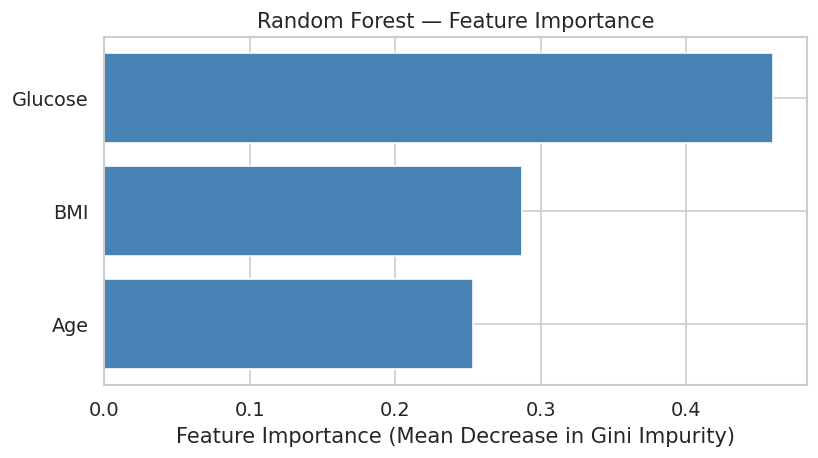

💡 Glucose is by far the most important feature — consistent with clinical
   guidelines where OGTT glucose is the primary diagnostic criterion.


In [ ]:
# ── Feature Importance from Random Forest ──
rf.fit(X, y)
importance_df = pd.DataFrame({
    'Feature': ['Glucose', 'BMI', 'Age'],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Gini Impurity)')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("💡 Glucose is by far the most important feature — consistent with clinical")
print("   guidelines where OGTT glucose is the primary diagnostic criterion.")


Note: Random Forest achieves the highest accuracy of the three models, but its behaviour splits the difference: better precision than Decision Tree (76.5% vs. 69.8%) but lower recall (64.8% vs. 71.6%). It's more conservative, fewer false alarms, but more missed cases. The 137 false positives are the lowest of any model, but 241 false negatives are the highest.


## 2.6 Model Comparison Which Algorithm Is Best?

Comparing models side by side on the same cross-validation folds ensures a fair comparison.


In [ ]:
# ══════════════════════════════════════════════
# MODEL COMPARISON
# ══════════════════════════════════════════════

X = features[['Glucose', 'BMI', 'Age']]
y = target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
}

print("═" * 65)
print("  MODEL COMPARISON 5-Fold Cross-Validation")
print("═" * 65)
print(f"  {'Model':25s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("─" * 65)

comparison_results = {}
for name, model in models.items():
    acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean()
    prec = cross_val_score(model, X, y, cv=cv, scoring='precision').mean()
    rec = cross_val_score(model, X, y, cv=cv, scoring='recall').mean()
    f1 = cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    comparison_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"  {name:25s} {acc:10.4f} {prec:10.4f} {rec:10.4f} {f1:10.4f}")

print("═" * 65)
print("\n💡 Compare not just accuracy but ALL metrics.")
print("   For diabetes screening, prioritise recall (catching all diabetic patients).")
print("   For treatment decisions, prioritise precision (avoiding false diagnoses).")


═════════════════════════════════════════════════════════════════
  MODEL COMPARISON 5-Fold Cross-Validation
═════════════════════════════════════════════════════════════════
  Model                       Accuracy  Precision     Recall         F1
─────────────────────────────────────────────────────────────────
  Logistic Regression           0.7685     0.7044     0.5570     0.6219
  Decision Tree                 0.7965     0.6975     0.7164     0.7067
  Random Forest                 0.8110     0.7645     0.6476     0.7003
═════════════════════════════════════════════════════════════════

💡 Compare not just accuracy but ALL metrics.
   For diabetes screening, prioritise recall (catching all diabetic patients).
   For treatment decisions, prioritise precision (avoiding false diagnoses).


**Note**: The "best" model depends on clinical context. For a population screening program where missing a diabetic patient has serious downstream consequences, the Decision Tree's higher recall (71.6%) is preferable. For a clinical decision support tool where a positive prediction triggers an expensive or invasive follow-up, the Random Forest's higher precision (76.5%) is more appropriate.


---

# Module 3: Unsupervised Learning — K-Means and Hierarchical Clustering

---

## 3.1 What Is Unsupervised Learning?

In unsupervised learning, there are **no labels**, the algorithm does not know the "correct answer." Instead, it discovers **hidden structure** in the data on its own.

**Clinical motivation: why do we need this?**

Supervised learning requires labelled data, but labelling is expensive, time-consuming, and sometimes impossible in medicine:
- What if you want to discover **new subtypes** of diabetes that haven't been defined yet?
- What if you want to group patients into **risk categories** without predefined thresholds?
- What if you want to find **natural groupings** in vital signs that might correspond to different disease processes?

### Clustering in Medicine Real-World Applications

| Application | How Clustering Helps |
|------------|---------------------|
| **Disease phenotyping** | Identifying subtypes of asthma, COPD, or sepsis based on biomarker patterns — each subtype may respond differently to treatment |
| **Patient stratification** | Grouping ICU patients by acuity patterns for targeted care pathways |
| **Treatment response** | Discovering groups of patients who respond similarly to a medication |
| **Epidemiology** | Identifying geographic or demographic clusters of disease outbreaks |
| **Genomics** | Grouping genes with similar expression patterns across tumour samples |

### Two Approaches We Will Cover

1. **K-Means Clustering**: partition-based: divides data into exactly K groups by minimising within-cluster distances
2. **Hierarchical Clustering**: builds a tree (dendrogram) showing how patients group together at different levels of similarity

---

## 3.2 K-Means Clustering

### Definition
K-Means partitions a dataset into **K groups (clusters)** by minimising the variance within each cluster. It is a **centroid-based** algorithm, each cluster is represented by its centre point (centroid).

### Algorithm Steps (Detailed)
1. **Choose K**: the number of clusters (this must be specified in advance)
2. **Initialise**: randomly place K centroids in the feature space
3. **Assign**: for each patient, calculate the distance to every centroid and assign the patient to the nearest one
4. **Update**: recalculate each centroid as the mean (average) of all patients assigned to it
5. **Repeat** steps 3–4 until the centroids stop moving (convergence) or a maximum number of iterations is reached

### How to Choose K, The Elbow Method
Since K must be specified in advance, we need a principled way to choose it:
1. Run K-Means for K = 1, 2, 3, ..., 10
2. For each K, record the **WCSS (Within-Cluster Sum of Squares)**, the total distance of each point to its assigned centroid
3. Plot WCSS vs. K → look for the **"elbow"**, the point where adding more clusters gives diminishing returns
4. The elbow point suggests the optimal K

### Why Feature Scaling Is Critical
K-Means uses **Euclidean distance** to assign patients to clusters. If features are on different scales (e.g., Glucose in mg/dL ranges 0–200 while BMI ranges 0–67), the larger-scale features will dominate the distance calculation. **Always standardise before clustering.**

### Strengths
- Fast and scalable, even for large datasets
- Simple to understand and implement
- Works well when clusters are roughly spherical and equally sized

### Weaknesses
- Must specify K in advance (may not be obvious)
- Sensitive to initial centroid placement (mitigated by running multiple initialisations: `n_init='auto'`)
- Assumes clusters are spherical and equally sized, struggles with elongated or irregular shapes
- Sensitive to outliers (a single extreme patient can shift a centroid)


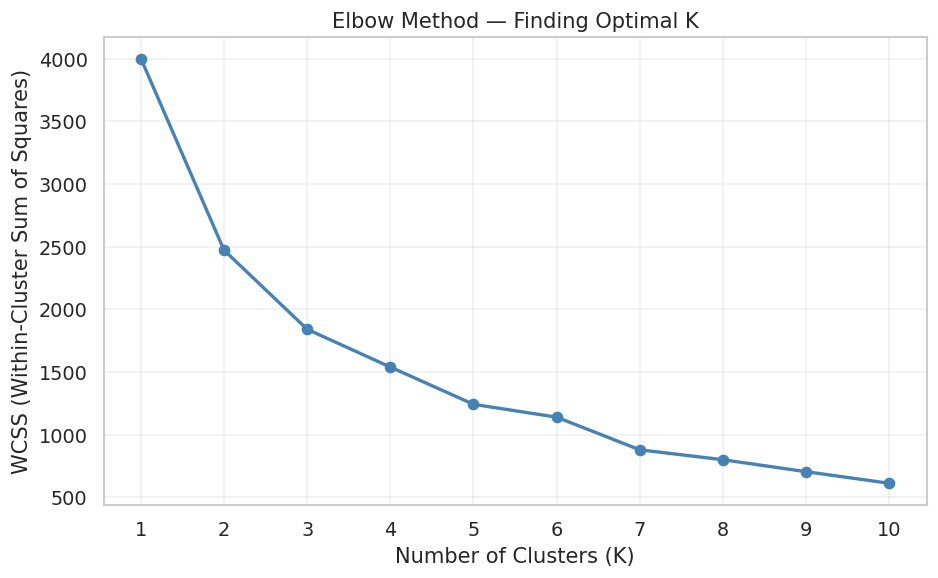

💡 Look for the 'elbow' — the point where the curve bends sharply.
   Beyond this point, adding more clusters yields diminishing returns.
   K = 3 appears to be a reasonable choice for this dataset.


In [ ]:
# ══════════════════════════════════════════════
# K-MEANS CLUSTERING
# ══════════════════════════════════════════════

# Select features for clustering
X_clust = features[['Glucose', 'BMI']]

# Standardise (CRITICAL for distance-based clustering)
scaler_cl = StandardScaler()
X_scaled = scaler_cl.fit_transform(X_clust)

# ── Elbow Method: finding optimal K ──
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, wcss, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method — Finding Optimal K')
ax.set_xticks(list(K_range))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Look for the 'elbow' — the point where the curve bends sharply.")
print("   Beyond this point, adding more clusters yields diminishing returns.")
print("   K = 3 appears to be a reasonable choice for this dataset.")


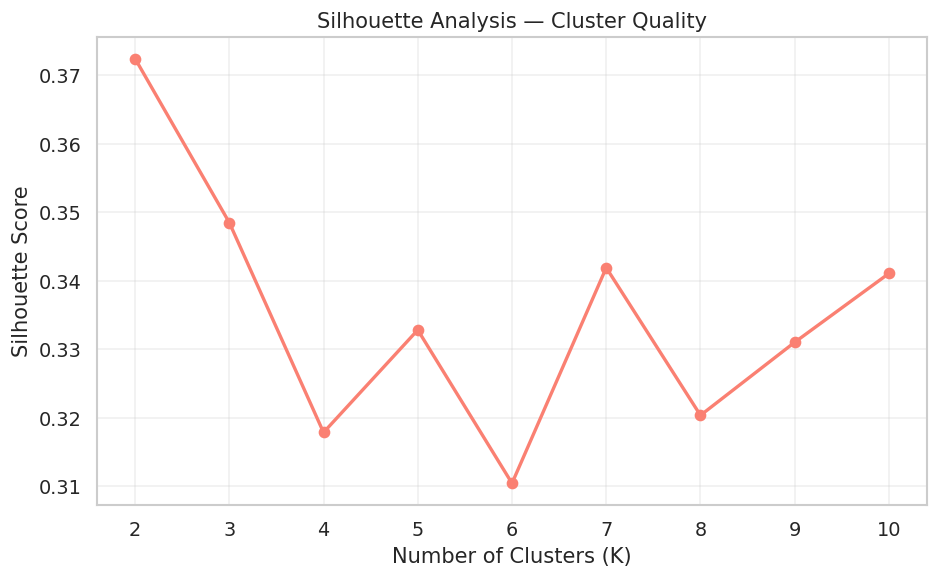

💡 Highest silhouette score at K = 2
   Silhouette score ranges from -1 to 1:
   • Close to 1: patients are well-matched to their cluster
   • Close to 0: patients are on the border between clusters
   • Negative: patients may be assigned to the wrong cluster


In [ ]:
# ── Silhouette analysis for additional validation ──
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, 11), sil_scores, 'o-', color='salmon', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis — Cluster Quality')
ax.set_xticks(range(2, 11))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = range(2, 11)[np.argmax(sil_scores)]
print(f"💡 Highest silhouette score at K = {best_k}")
print("   Silhouette score ranges from -1 to 1:")
print("   • Close to 1: patients are well-matched to their cluster")
print("   • Close to 0: patients are on the border between clusters")
print("   • Negative: patients may be assigned to the wrong cluster")


**Note**: The silhouette analysis suggested K=2 is actually the most natural split (likely: high-glucose vs. normal-glucose). K=3 adds the BMI-based distinction, which is clinically useful even if the statistical separation is less clean.


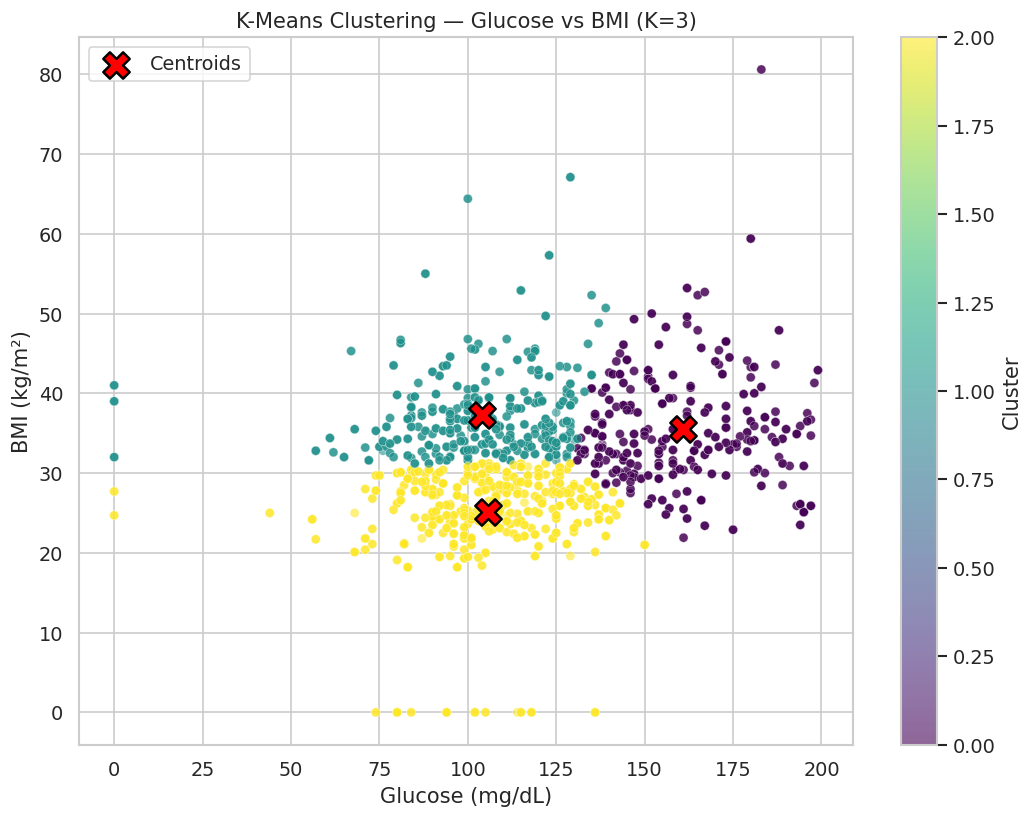

In [ ]:
# ── Apply K-Means with K = 3 ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)
diabetes_data['KMeans_Cluster'] = cluster_labels

# ── Visualise clusters ──
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_clust['Glucose'], X_clust['BMI'],
                     c=cluster_labels, cmap='viridis', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

# Plot centroids (transformed back to original scale)
centroids_original = scaler_cl.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids_original[:, 0], centroids_original[:, 1],
           s=250, c='red', marker='X', edgecolor='black', linewidth=1.5,
           label='Centroids', zorder=5)

ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('BMI (kg/m²)')
ax.set_title('K-Means Clustering — Glucose vs BMI (K=3)')
ax.legend()
legend = fig.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()


In [ ]:
# ── Clinical interpretation of clusters ──
cluster_profiles = diabetes_data.groupby('KMeans_Cluster')[
    ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']
].mean().round(1)

print("══════════════════════════════════════════════════════════")
print("  CLUSTER PROFILES Mean Values per Cluster")
print("══════════════════════════════════════════════════════════")
print(cluster_profiles.to_string())
print("══════════════════════════════════════════════════════════")

print("\n💡 Clinical interpretation:")
for c in range(3):
    row = cluster_profiles.loc[c]
    n = (diabetes_data['KMeans_Cluster'] == c).sum()
    diabetes_pct = row['Outcome'] * 100
    print(f"\n  Cluster {c} (n={n}):")
    print(f"    Glucose: {row['Glucose']:.0f} mg/dL | BMI: {row['BMI']:.1f} | "
          f"Age: {row['Age']:.0f} | Diabetes rate: {diabetes_pct:.0f}%")

    descriptors = []
    if row['Glucose'] > 140: descriptors.append("high glucose")
    elif row['Glucose'] < 110: descriptors.append("normal glucose")
    if row['BMI'] > 33: descriptors.append("obese")
    elif row['BMI'] < 28: descriptors.append("normal/overweight BMI")
    if diabetes_pct > 50: descriptors.append("HIGH diabetes prevalence")
    elif diabetes_pct < 25: descriptors.append("low diabetes prevalence")
    print(f"    → {', '.join(descriptors) if descriptors else 'moderate risk profile'}")


══════════════════════════════════════════════════════════
  CLUSTER PROFILES Mean Values per Cluster
══════════════════════════════════════════════════════════
                Glucose   BMI   Age  BloodPressure  Insulin  Outcome
KMeans_Cluster                                                      
0                 160.7  35.5  37.3           73.1    129.1      0.7
1                 104.1  37.3  32.0           71.6     72.8      0.3
2                 105.8  25.2  30.8           63.9     49.2      0.1
══════════════════════════════════════════════════════════

💡 Clinical interpretation:

  Cluster 0 (n=581):
    Glucose: 161 mg/dL | BMI: 35.5 | Age: 37 | Diabetes rate: 70%
    → high glucose, obese, HIGH diabetes prevalence

  Cluster 1 (n=664):
    Glucose: 104 mg/dL | BMI: 37.3 | Age: 32 | Diabetes rate: 30%
    → normal glucose, obese

  Cluster 2 (n=755):
    Glucose: 106 mg/dL | BMI: 25.2 | Age: 31 | Diabetes rate: 10%
    → normal glucose, normal/overweight BMI, low diabetes preva

**Note**: This is a clinically meaningful stratification. Cluster 0 is the clear high-risk group: these patients likely already meet diagnostic criteria. Cluster 1 is the interesting one: obese patients with normal glucose: they have a 30% diabetes rate, meaning they are at elevated risk and could benefit from lifestyle interventions and closer monitoring before they progress. Cluster 2 represents the metabolically healthiest group.


---

## 3.3 Hierarchical (Agglomerative) Clustering

### Definition
Hierarchical clustering builds a **tree-like structure (dendrogram)** that shows how patients group together at every level of similarity. Unlike K-Means, you do **not** need to specify K in advance. Uou can cut the tree at any height to get any number of clusters.

### Algorithm Steps (Agglomerative, "Bottom-Up")
1. **Start:** Each patient is its own cluster (N clusters for N patients)
2. **Merge:** Find the two most similar clusters and merge them into one
3. **Repeat:** Continue merging until all patients are in a single cluster
4. **Visualise:** The **dendrogram** shows the full merging history, the height of each merge indicates how dissimilar the clusters were

### Linkage Methods: How "Similarity" Is Defined

| Linkage | Merges Based On | Best For |
|---------|-----------------|---------|
| **Ward** | Minimises total within-cluster variance | Compact, roughly equal-sized clusters (most commonly used) |
| **Complete** | Maximum distance between any two points in different clusters | Well-separated clusters |
| **Average** | Mean distance between all pairs of points across clusters | General purpose, less sensitive to outliers |
| **Single** | Minimum distance between any two points across clusters | Detecting elongated clusters (but can create "chaining" artefacts) |

### Reading a Dendrogram
- **X-axis:** Patients or groups of patients
- **Y-axis:** Distance (dissimilarity) at which groups are merged
- **Horizontal cut:** Drawing a horizontal line at a given height determines the number of clusters, count the number of vertical lines the cut crosses
- **Tall branches:** Indicate well-separated clusters; short branches indicate closely related groups

### Advantages over K-Means
- No need to specify K in advance
- Produces a full hierarchy that can be cut at any level
- The dendrogram provides intuitive visualisation of data structure
- Doesn't assume spherical clusters

### Disadvantages
- Computationally expensive for large datasets (O(n²) memory, O(n³) time)
- Once a merge is made, it cannot be undone, early "mistakes" propagate
- Not practical for very large datasets (>10,000 patients)

---


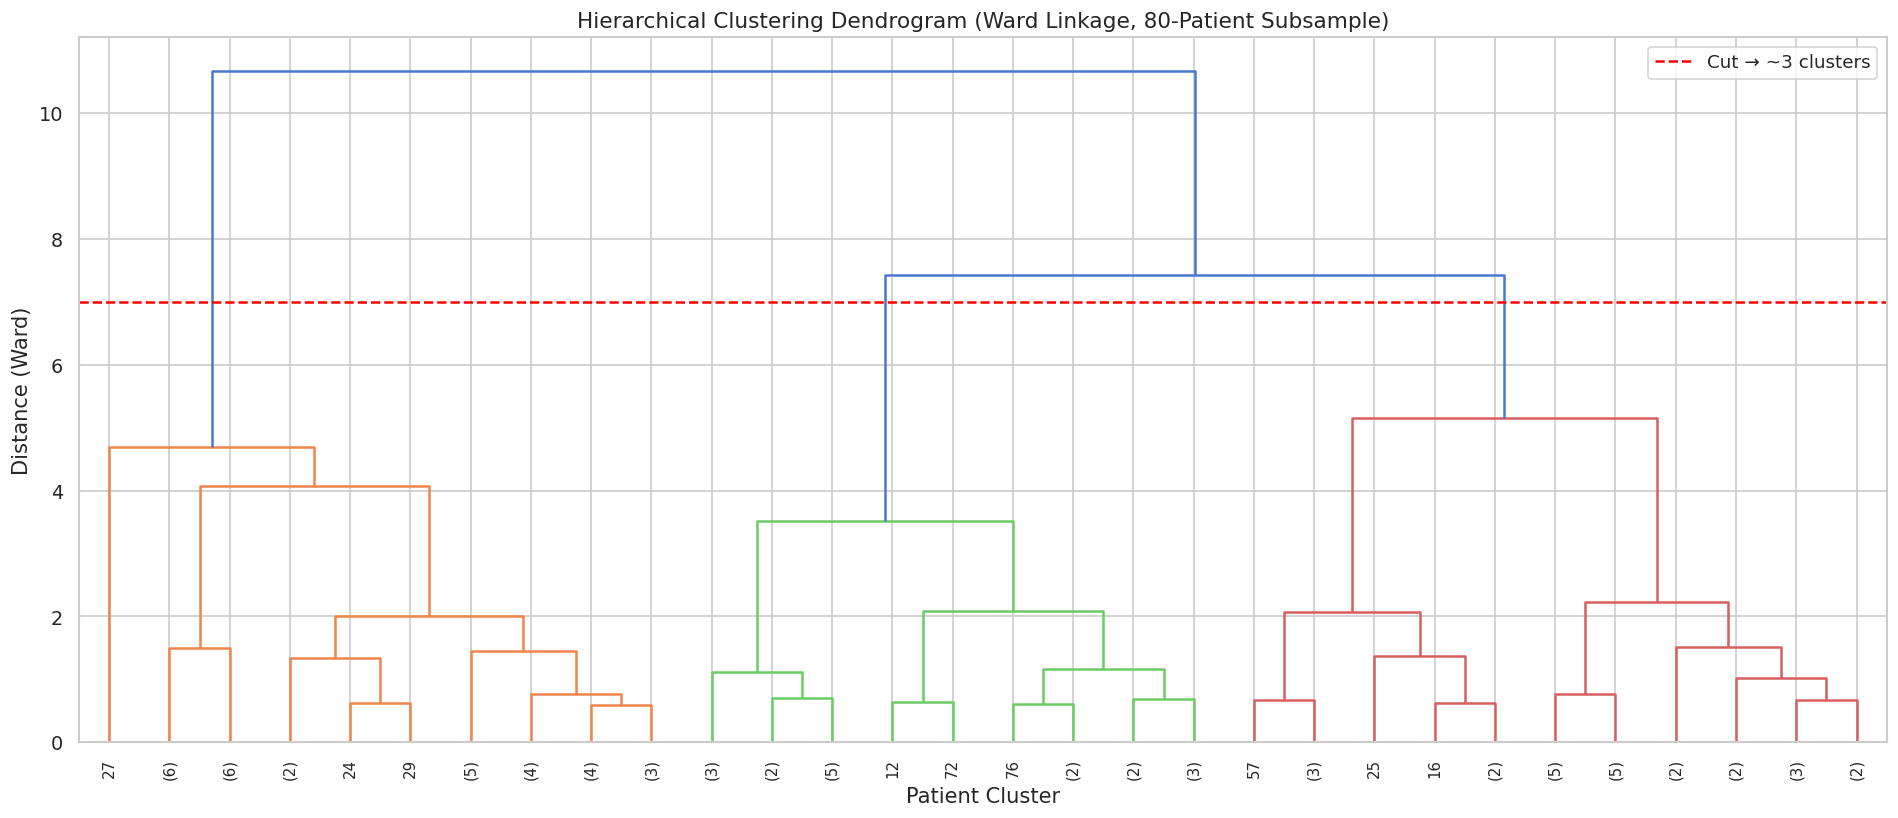

💡 How to read this dendrogram:
   • Each vertical line represents a merge of two clusters
   • The HEIGHT of the merge = how dissimilar the clusters were
   • The red dashed line shows where to cut to get approximately 3 clusters
   • Cutting at a lower height gives more clusters; higher gives fewer


In [ ]:
# ══════════════════════════════════════════════
# HIERARCHICAL CLUSTERING
# ══════════════════════════════════════════════

# Use the same scaled features
# For hierarchical clustering dendrograms, we subsample for visual clarity
np.random.seed(42)
n_sub = 80  # subsample for readable dendrogram
idx_sub = np.random.choice(len(X_scaled), size=n_sub, replace=False)
X_sub = X_scaled[idx_sub]

# ── Compute linkage matrix ──
Z = linkage(X_sub, method='ward')

# ── Plot dendrogram ──
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, ax=ax, color_threshold=7)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, 80-Patient Subsample)', fontsize=13)
ax.set_xlabel('Patient Cluster')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=7, color='red', linestyle='--', linewidth=1.5, label='Cut → ~3 clusters')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("💡 How to read this dendrogram:")
print("   • Each vertical line represents a merge of two clusters")
print("   • The HEIGHT of the merge = how dissimilar the clusters were")
print("   • The red dashed line shows where to cut to get approximately 3 clusters")
print("   • Cutting at a lower height gives more clusters; higher gives fewer")


Adjusted Rand Index (K-Means vs Hierarchical): 0.369
  (1.0 = identical clustering, 0.0 = random agreement)



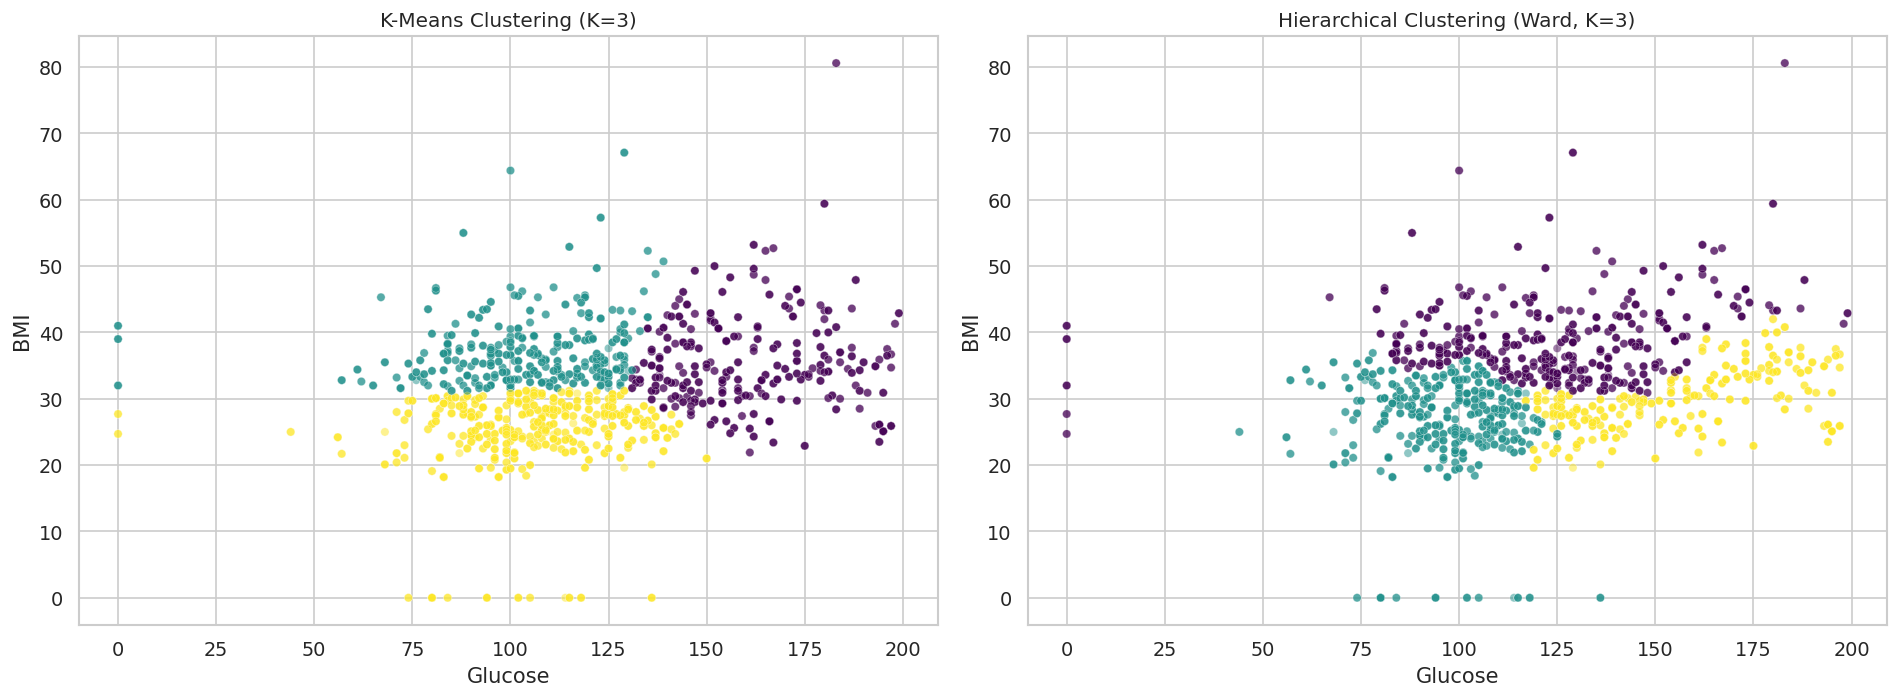

💡 ARI = 0.37 — the two methods show moderate agreement.
   When both methods find similar groups, we gain confidence the structure is real
   and not an artefact of a particular algorithm.


In [ ]:
# ── Apply Hierarchical Clustering to full dataset ──
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
diabetes_data['HC_Cluster'] = hc_labels

# ── Compare with K-Means ──
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(cluster_labels, hc_labels)

print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}")
print(f"  (1.0 = identical clustering, 0.0 = random agreement)\n")

# ── Side-by-side visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_clust['Glucose'], X_clust['BMI'],
                c=cluster_labels, cmap='viridis', alpha=0.5, s=25, edgecolors='white', linewidth=0.3)
axes[0].set_title('K-Means Clustering (K=3)', fontsize=12)
axes[0].set_xlabel('Glucose'); axes[0].set_ylabel('BMI')

axes[1].scatter(X_clust['Glucose'], X_clust['BMI'],
                c=hc_labels, cmap='viridis', alpha=0.5, s=25, edgecolors='white', linewidth=0.3)
axes[1].set_title('Hierarchical Clustering (Ward, K=3)', fontsize=12)
axes[1].set_xlabel('Glucose'); axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

print(f"💡 ARI = {ari:.2f} — the two methods show "
      f"{'strong' if ari > 0.6 else 'moderate' if ari > 0.3 else 'weak'} agreement.")
print("   When both methods find similar groups, we gain confidence the structure is real")
print("   and not an artefact of a particular algorithm.")


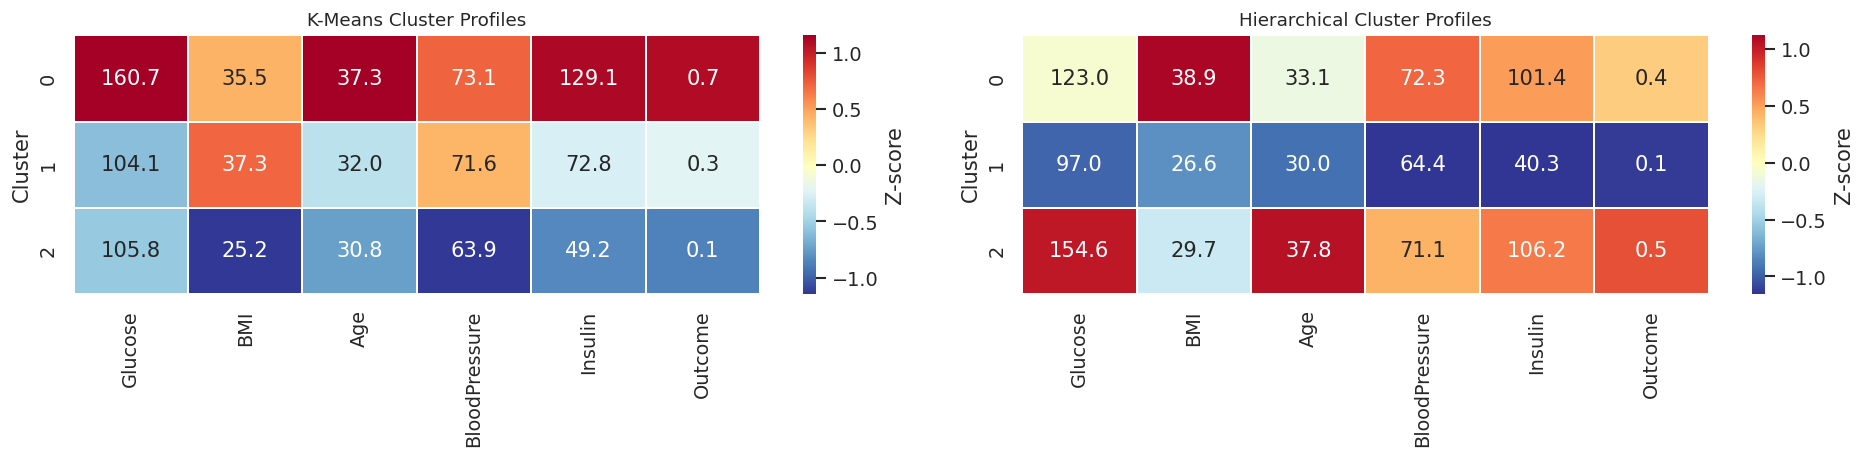

💡 The heatmaps show cluster profiles from both methods.
   Colour = relative z-score (red = above average, blue = below average)
   Numbers = actual mean values for clinical interpretation


In [ ]:
# ── Cluster profile comparison as heatmap ──
hc_profiles = diabetes_data.groupby('HC_Cluster')[
    ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']
].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, profiles, title in zip(axes,
    [cluster_profiles, hc_profiles],
    ['K-Means Cluster Profiles', 'Hierarchical Cluster Profiles']):

    # Z-score for colour, raw values for annotations
    profile_z = (profiles - profiles.mean()) / profiles.std()
    sns.heatmap(profile_z, annot=profiles.values, fmt='.1f', cmap='RdYlBu_r',
                center=0, ax=ax, linewidths=1, cbar_kws={'label': 'Z-score'})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Cluster')

plt.tight_layout()
plt.show()

print("💡 The heatmaps show cluster profiles from both methods.")
print("   Colour = relative z-score (red = above average, blue = below average)")
print("   Numbers = actual mean values for clinical interpretation")


Note: What this means in practice: they agreed on the "easy" cases but diverged on the borderline ones. The high-glucose cluster (Cluster 0): the 581 patients with mean glucose of 161 mg/dL, BMI 35.5, and 70% diabetes rate, was identified by both methods. That's the clearest, most separated group in the data, so both algorithms pick it up reliably.


Where they diverged was in how they split the remaining patients between Clusters 1 and 2. K-Means drew the boundary primarily on BMI (37.3 vs. 25.2), since it uses Euclidean distance from centroids and BMI had the biggest spread after glucose. Hierarchical clustering with Ward linkage minimises within-cluster variance, which can weight the features differently and draw the cut in a slightly different place. So some patients that K-Means put in the "obese, normal glucose" group, hierarchical clustering placed in the "healthy weight" group, or vice versa.



This is actually a useful finding as it tells you that the three-tier risk stratification (high glucose/high risk → obese but normal glucose/moderate risk → healthy weight/low risk) is a real structure in the data, but the exact boundary between the moderate and low-risk groups is a clinical spectrum rather than a sharp line. The silhouette analysis reinforces this: it suggested K=2 was the most natural split (essentially just high glucose vs. not), and K=3 adds a BMI-based distinction that's clinically useful but statistically fuzzier.


For clinical purposes, both methods tell the same story: glucose is the dominant separator, and BMI provides a secondary stratification within the normal-glucose patients. The moderate ARI is expected and not a concern. It would only be worrying if the methods produced completely contradictory groupings.

---

# Module 4: Implementation of Machine Learning Methods

---

## 4.1 From Experiment to Production: The Complete ML Workflow

This module brings everything together into a **production-ready workflow** that reflects how ML is implemented in clinical research and health-system analytics. The key difference between a classroom exercise and a real clinical ML project is **rigour** — every step must be documented, reproducible, and resistant to common pitfalls.

### The Five Pillars of Robust Medical ML

**1. Reproducibility**
- Set random seeds, log all hyperparameters, version your data
- Another researcher should be able to reproduce your exact results
- In our notebook: `random_state=42` everywhere

**2. Prevention of Data Leakage**
- ALL preprocessing (imputation, scaling, feature selection) must be fit on training data only
- The test set must remain completely untouched until final evaluation
- Using a Pipeline ensures this automatically

**3. Robust Evaluation**
- Never rely on a single train/test split — use cross-validation
- Report mean ± standard deviation, not a single number
- Report multiple metrics, not just accuracy

**4. Clinical Relevance**
- Metrics must be clinically meaningful (sensitivity for screening, specificity for confirmation)
- Model calibration matters — does a predicted 30% risk really mean 30%?
- The model must be interpretable enough for clinical adoption

**5. Fairness and Safety**
- Check performance across demographic subgroups
- Plan for deployment, monitoring, and retraining

---

## 4.2 Building a Scikit-Learn Pipeline

A `Pipeline` chains preprocessing and modelling steps together, ensuring:
- The scaler/imputer is fit on training data only (no leakage)
- The entire workflow is encapsulated in a single object
- Cross-validation is applied to the entire pipeline, not just the model
- Deployment is simpler — one object handles everything from raw data to prediction


In [ ]:
# ══════════════════════════════════════════════
# COMPLETE PIPELINE — End-to-End
# ══════════════════════════════════════════════

# Use ALL features (not just the top 3)
X_all = features.copy()
y_all = target.copy()

# ── Build pipeline ──
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Handle any missing values
    ("scaler",  StandardScaler()),                    # Standardise features
    ("model",   LogisticRegression(max_iter=1000, random_state=42))
])

# ── Stratified train/test split ──
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# ── Fit the pipeline ──
pipe.fit(X_tr, y_tr)
y_pred_pipe = pipe.predict(X_te)
y_prob_pipe = pipe.predict_proba(X_te)[:, 1]

print("═" * 55)
print("  COMPLETE PIPELINE — All Features, Logistic Regression")
print("═" * 55)
print(f"  Accuracy  : {accuracy_score(y_te, y_pred_pipe):.4f}")
print(f"  Precision : {precision_score(y_te, y_pred_pipe):.4f}")
print(f"  Recall    : {recall_score(y_te, y_pred_pipe):.4f}")
print(f"  F1-Score  : {f1_score(y_te, y_pred_pipe):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_te, y_prob_pipe):.4f}")
print("═" * 55)
print("\n✅ The pipeline handles imputation → scaling → prediction")
print("   in a single .fit() / .predict() call — no data leakage possible.")
print("   Using all 8 features instead of just 3 may improve performance.")


═══════════════════════════════════════════════════════
  COMPLETE PIPELINE — All Features, Logistic Regression
═══════════════════════════════════════════════════════
  Accuracy  : 0.8025
  Precision : 0.7736
  Recall    : 0.5985
  F1-Score  : 0.6749
  AUC-ROC   : 0.8460
═══════════════════════════════════════════════════════

✅ The pipeline handles imputation → scaling → prediction
   in a single .fit() / .predict() call — no data leakage possible.
   Using all 8 features instead of just 3 may improve performance.


## 4.3 Cross-Validation on the Full Pipeline

Applying cross-validation to the entire pipeline (not just the model) ensures that imputation and scaling are done correctly within each fold — no information leaks from the validation fold into the training process.


In [ ]:
# ── 5-Fold Cross-Validation on the full pipeline ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='roc_auc')
cv_acc = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='f1')

print("═" * 60)
print("  5-FOLD CROSS-VALIDATION — Full Pipeline (All Features)")
print("═" * 60)
print(f"\n  {'Metric':15s} {'Mean':>8s} {'Std':>8s} {'95% CI':>20s}")
print("  " + "─" * 52)
for name, scores in [('AUC-ROC', cv_auc), ('Accuracy', cv_acc), ('F1-Score', cv_f1)]:
    lo = scores.mean() - 1.96 * scores.std()
    hi = scores.mean() + 1.96 * scores.std()
    print(f"  {name:15s} {scores.mean():8.4f} {scores.std():8.4f}   [{lo:.4f}, {hi:.4f}]")

print("\n" + "═" * 60)
print("\n💡 The confidence interval tells you the range in which the true")
print("   performance is likely to fall. Narrow CI = stable model.")


════════════════════════════════════════════════════════════
  5-FOLD CROSS-VALIDATION — Full Pipeline (All Features)
════════════════════════════════════════════════════════════

  Metric              Mean      Std               95% CI
  ────────────────────────────────────────────────────
  AUC-ROC           0.8334   0.0181   [0.7979, 0.8689]
  Accuracy          0.7815   0.0159   [0.7503, 0.8127]
  F1-Score          0.6388   0.0222   [0.5952, 0.6823]

════════════════════════════════════════════════════════════

💡 The confidence interval tells you the range in which the true
   performance is likely to fall. Narrow CI = stable model.


**Note**: Using all features through a proper pipeline: AUC = 0.846, Accuracy = 80.3%, F1 = 0.67. The 5-fold CV gives AUC = 0.833 [0.798, 0.869]. Interestingly, using all 8 features doesn't dramatically improve over using just Glucose, BMI, and Age — this confirms that those three features carry most of the predictive signal, and the others (especially Insulin and SkinThickness with all their missing data) add relatively little.


## 4.4 Model Calibration

Calibration answers the question: **"When the model says 30% risk, do 30% of those patients actually have diabetes?"**

This is critically important in medicine because predicted probabilities are often communicated directly to patients and used for shared decision-making. A model that says "80% chance of diabetes" but is only right 50% of the time is dangerously misleading.

A **well-calibrated** model's predicted probabilities closely match observed frequencies. Logistic regression is typically well-calibrated by default. More complex models (Random Forest, neural networks) often need recalibration.


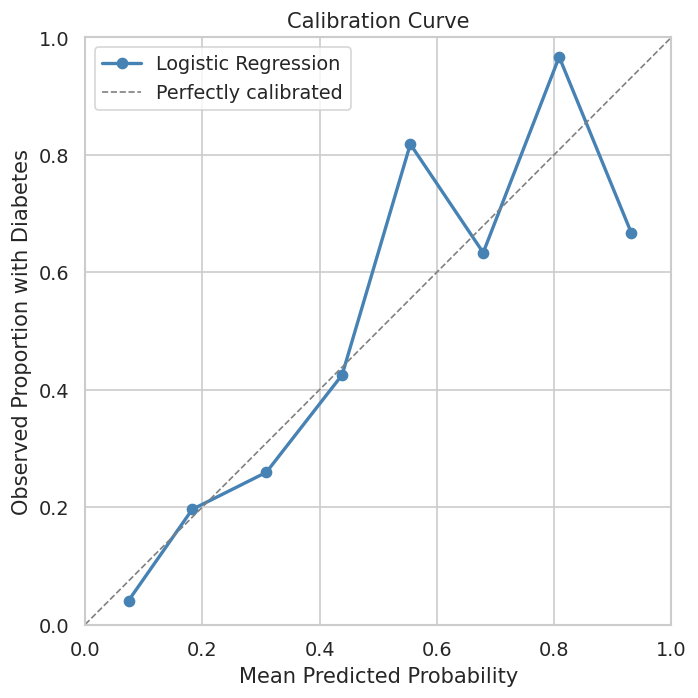

💡 Points close to the diagonal = well-calibrated model
   If the curve is above the diagonal: the model underestimates risk
   If the curve is below: the model overestimates risk
   Logistic regression is typically well-calibrated out of the box.


In [ ]:
# ── Calibration Curve ──
prob_true, prob_pred = calibration_curve(y_te, y_prob_pipe, n_bins=8, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, 'o-', color='steelblue', linewidth=2, label='Logistic Regression')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1, label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Proportion with Diabetes')
ax.set_title('Calibration Curve')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("💡 Points close to the diagonal = well-calibrated model")
print("   If the curve is above the diagonal: the model underestimates risk")
print("   If the curve is below: the model overestimates risk")
print("   Logistic regression is typically well-calibrated out of the box.")


## 4.5 Comprehensive Model Comparison

Let's compare all models we've covered on the full dataset using all features and proper pipelines.


In [ ]:
# ══════════════════════════════════════════════
# COMPREHENSIVE MODEL COMPARISON
# ══════════════════════════════════════════════

X_all = features.copy()
y_all = target.copy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Baseline (Always Majority)': Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    'Logistic Regression': Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1))
    ]),
}

print("═" * 75)
print("  COMPREHENSIVE MODEL COMPARISON — 5-Fold CV, All Features")
print("═" * 75)
print(f"  {'Model':30s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("─" * 75)

all_results = {}
for name, pipe in pipelines.items():
    scores = {}
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        s = cross_val_score(pipe, X_all, y_all, cv=cv, scoring=metric)
        scores[metric] = s.mean()
    all_results[name] = scores
    print(f"  {name:30s} {scores['accuracy']:10.4f} {scores['precision']:10.4f} "
          f"{scores['recall']:10.4f} {scores['f1']:10.4f}")

print("═" * 75)
print("\n💡 Key observations:")
print("   • All models should substantially beat the baseline to be useful")
print("   • Random Forest often achieves the best overall performance")
print("   • Logistic Regression offers the best interpretability")
print("   • The 'best' model depends on the clinical priority (recall vs precision)")


═══════════════════════════════════════════════════════════════════════════
  COMPREHENSIVE MODEL COMPARISON — 5-Fold CV, All Features
═══════════════════════════════════════════════════════════════════════════
  Model                            Accuracy  Precision     Recall         F1
───────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

  Baseline (Always Majority)         0.6580     0.0000     0.0000     0.0000
  Logistic Regression                0.7815     0.7368     0.5644     0.6388
  Decision Tree                      0.8080     0.7407     0.6814     0.7079
  Random Forest                      0.8255     0.8109     0.6389     0.7143
═══════════════════════════════════════════════════════════════════════════

💡 Key observations:
   • All models should substantially beat the baseline to be useful
   • Random Forest often achieves the best overall performance
   • Logistic Regression offers the best interpretability
   • The 'best' model depends on the clinical priority (recall vs precision)


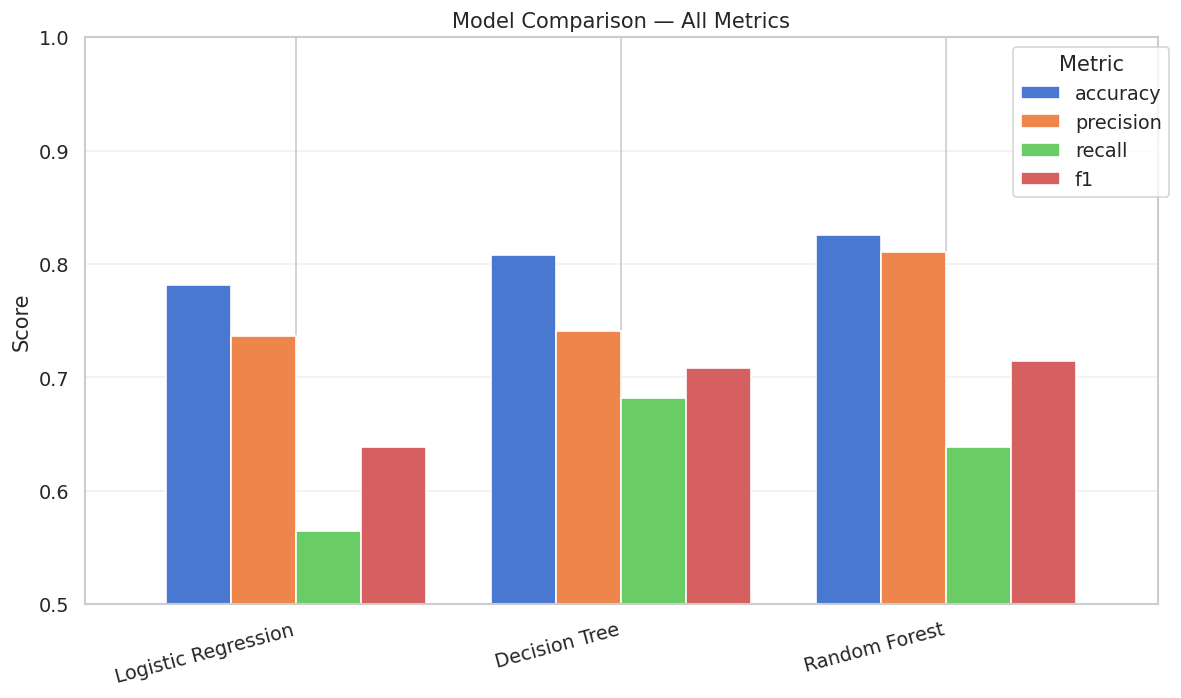

In [ ]:
# ── Visual comparison ──
results_df = pd.DataFrame(all_results).T
results_df = results_df.drop('Baseline (Always Majority)')

fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1))
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4.6 Clinical Deployment Considerations

### Before Deploying an ML Model in a Clinical Setting

**Technical Checklist:**
- ☐ External validation on an independent cohort (different institution, different time period)
- ☐ Subgroup analysis — does the model perform equally well across age groups, sexes, and ethnicities?
- ☐ Calibration assessment — are predicted probabilities trustworthy?
- ☐ Sensitivity analysis — how does performance change with missing data?
- ☐ Comparison against existing clinical tools (e.g., does the ML model beat the Finnish Diabetes Risk Score?)

**Clinical Integration:**
- ☐ Does the model output integrate into existing EHR workflows (e.g., Epic, Cerner)?
- ☐ Is there a clear action pathway when the model flags a patient? (e.g., order OGTT, refer to endocrine)
- ☐ Who is accountable for model-informed decisions?
- ☐ Is there a clinician override mechanism?
- ☐ How will the model's predictions be communicated to patients?

**Regulatory & Ethical:**
- ☐ Does the model qualify as Software as a Medical Device (SaMD)?
- ☐ Has it been reviewed by an institutional ethics board / REB?
- ☐ Is there a plan for ongoing monitoring and retraining as patient populations change?
- ☐ Are patients informed that ML is being used in their care?
- ☐ Has the model been assessed for algorithmic bias and fairness?

**Important limitation of this dataset:** The Pima Indians Diabetes Dataset contains only female patients of Pima Indian heritage aged ≥ 21. A model trained on this data **should not be deployed** for male patients, other ethnicities, or younger patients without separate validation — this would be a critical failure of generalisation.

---

## 4.7 Summary

| Module | Key Takeaway |
|--------|-------------|
| **1. Introduction** | ML learns patterns from data; medical AI requires special care around bias, missing data, and clinical validation |
| **2. Supervised Learning** | Linear regression predicts continuous outcomes; logistic regression predicts binary events; decision trees and random forests offer flexibility; cross-validation provides robust evaluation |
| **3. Unsupervised Learning** | K-Means partitions patients into K groups; hierarchical clustering builds a dendrogram; both methods should be validated with domain knowledge |
| **4. Implementation** | Use Pipelines to prevent leakage, cross-validation for robust estimates, calibration for clinical trust, and thorough planning for deployment |

### Recommended Next Steps
1. **Extend the models:** Try using all features instead of just three; experiment with regularisation (Lasso, Ridge)
2. **Handle missing data properly:** Replace zeros with NaN and use imputation strategies
3. **Try additional datasets:** The [Heart Disease UCI](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data) or [Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) datasets are excellent for practice
4. **Read:** *Clinical Prediction Models* by Ewout Steyerberg — the gold standard textbook for medical prediction modelling

---

*Notebook created for educational purposes. The Pima Indians Diabetes Dataset is from the National Institute of Diabetes and Digestive and Kidney Diseases. Clinical decisions should never be based solely on algorithmic predictions.*
